# NB03f — Data Treatment Decisions

**Decision document, not a data-transformation pipeline.**  
Inventories NaN patterns, outlier statistics, log-ratio redundancies, and feature eligibility
for each ML configuration (C1 and C8 primary). Records treatment policies in SQLite and JSON.

**Does NOT impute, winsorize, scale, or otherwise mutate `measurements` or `diagnostic_ratios`.**

Outputs:
- 6 SQLite tables (`treatment_decisions`, `feature_ml_eligibility`, `shap_feature_groups`,
  `log_ratio_redundancy`, `feature_nan_profile`, `feature_conditional_value`)
- 2 JSON exports (`treatment_decisions.json`, `shap_feature_groups.json`)
- 7 diagnostic figures (`figures/nb03f/`)

**Vocabulary discipline (GUARDRAILS §16):**
NO process/identity binary labels. Say "evaporation-sensitive" and "evaporation-resistant".

In [1]:
# Cell 0 — Imports and setup

import sqlite3
import json
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as sp_stats
from IPython.display import Image, display
import sys

sys.path.insert(0, str(Path('..') / 'notebooks'))
from utils import SEED, PROJECT_ROOT, DB_PATH, FIG_ROOT, abbrev, setup_figure_style

np.random.seed(SEED)
setup_figure_style()

FIG_DIR = FIG_ROOT / 'nb03f'
if FIG_DIR.exists():
    shutil.rmtree(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

NB_OUT_DIR = PROJECT_ROOT / 'data' / 'processed' / 'nb03f_policies'
NB_OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'DB: {DB_PATH} exists={DB_PATH.exists()}')
print(f'Figures  -> {FIG_DIR}')
print(f'Policies -> {NB_OUT_DIR}')

DB: C:\Users\leogr\Documents\Data Science\TCC\data\processed\weathering.db exists=True
Figures  -> C:\Users\leogr\Documents\Data Science\TCC\figures\nb03f
Policies -> C:\Users\leogr\Documents\Data Science\TCC\data\processed\nb03f_policies


In [2]:
# Cell 1 — DB connection and sanity checks
# Uses sqlite3.connect() directly (not get_conn context manager)
# because NB03f needs conn/cur across multiple cells and uses executescript().

conn = sqlite3.connect(str(DB_PATH))
conn.execute('PRAGMA foreign_keys = ON')
cur = conn.cursor()

checks = {
    'oils_included':        'SELECT COUNT(*) FROM oils WHERE include_in_analysis=1',
    'compounds_active':     'SELECT COUNT(*) FROM compounds WHERE excluded=0',
    'measurements':         'SELECT COUNT(*) FROM measurements',
    'diagnostic_ratios':    'SELECT COUNT(*) FROM diagnostic_ratios',
    'D14_NULL_rows':        'SELECT COUNT(*) FROM measurements WHERE value_imputed IS NULL',
    'D15_positive_imputed': 'SELECT COUNT(*) FROM measurements WHERE is_imputed=1 AND value_imputed > 0',
}
state = {k: cur.execute(q).fetchone()[0] for k, q in checks.items()}
for k, v in state.items():
    print(f'  {k:28s}: {v}')

# Hard gates
assert state['oils_included'] > 0, 'No oils included'
assert state['compounds_active'] == 92, f"Expected 92 compounds, got {state['compounds_active']}"
assert state['D15_positive_imputed'] == 0, f"D15 violated: {state['D15_positive_imputed']} positive imputed"
assert state['D14_NULL_rows'] > 500, f"D14 NULLs suspiciously low ({state['D14_NULL_rows']})"

# Oil type distribution
oil_types_df = pd.read_sql(
    'SELECT oil_type, COUNT(*) AS n FROM oils WHERE include_in_analysis=1 GROUP BY oil_type ORDER BY n DESC',
    conn
)
print('\nOil type distribution (included):')
print(oil_types_df.to_string(index=False))
OIL_TYPES = sorted(oil_types_df['oil_type'].tolist())

print('\n✅ Sanity checks passed')

  oils_included               : 62
  compounds_active            : 92
  measurements                : 36594
  diagnostic_ratios           : 22680
  ratio_classification        : 108
  D14_NULL_rows               : 14003
  D15_positive_imputed        : 0

Derived tier counts (crude-only, excluding insufficient_data):
  Tier 1: 24
  Tier 2: 9
  Tier 3: 55
  Untestable (insufficient_data): 20
  Total testable: 88

Oil type distribution (included):
     oil_type  n
        crude 44
bitumen_blend  9
      refined  7
    synthetic  2

✅ Sanity checks passed


---
## Section 1 — NaN Inventory (Decision 1a)

A feature is ML-eligible for a given configuration if its non-NaN presence is ≥80%
in at least one relevant oil_type. Threshold: `threshold_nan_pct = 0.20` (i.e., 80% non-NaN).

Targets **MNAR structural** absence (GUARDRAILS §3b.1): H30 in refined gasolines,
extended hopanes in condensates, aromatic sulfur compounds in light synthetic oils.
Such features must be excluded rather than imputed.

In [3]:
# Cell S1.1 — Compute NaN matrix (features × oil_type)

q_comp = """
SELECT o.oil_id, o.oil_name, o.oil_type,
       m.stage_code,
       c.compound_id, c.compound_name, c.compound_group,
       m.value_imputed
FROM measurements m
JOIN oils o      ON m.oil_id = o.oil_id
JOIN compounds c ON m.compound_id = c.compound_id
WHERE o.include_in_analysis = 1 AND c.excluded = 0
"""
meas = pd.read_sql(q_comp, conn)
print(f'Compound measurements: {len(meas):,} rows')
print(f'  oil_type distribution (unique oils):')
print(meas[['oil_name','oil_type']].drop_duplicates()['oil_type']
      .value_counts().to_string())

q_rat = """
SELECT o.oil_id, o.oil_name, o.oil_type,
       dr.stage_code, dr.ratio_name, dr.value
FROM diagnostic_ratios dr
JOIN oils o ON dr.oil_id = o.oil_id
WHERE o.include_in_analysis = 1
"""
ratios = pd.read_sql(q_rat, conn)
print(f'\nRatio values: {len(ratios):,} rows')
print(f'  Unique ratios: {ratios["ratio_name"].nunique()}')

# Presence matrix: fraction non-NaN across (oil × stage) per oil_type
presence_compound = (
    meas.assign(present=meas['value_imputed'].notna().astype(int))
        .groupby(['compound_name', 'compound_group', 'oil_type'])
        ['present'].mean()
        .unstack('oil_type')
        .fillna(0.0)
)

presence_ratio = (
    ratios.assign(present=ratios['value'].notna().astype(int))
          .groupby(['ratio_name', 'oil_type'])
          ['present'].mean()
          .unstack('oil_type')
          .fillna(0.0)
)

print(f'\nCompound presence matrix: {presence_compound.shape}')
print(f'Ratio presence matrix:    {presence_ratio.shape}')

Compound measurements: 23,644 rows
  oil_type distribution (unique oils):
oil_type
crude            44
bitumen_blend     9
refined           7
synthetic         2

Ratio values: 22,680 rows
  Unique ratios: 108

Compound presence matrix: (92, 4)
Ratio presence matrix:    (108, 4)


In [4]:
# Cell S1.2 — Classify MNAR type per feature (§3b.1 taxonomy)

def classify_mnar(pres_values):
    """
    Three-class MNAR taxonomy (GUARDRAILS §3b.1):
      - structural:     compound genuinely absent from one oil_type by design
                        (>=80% presence in >=1 type AND <50% in >=1 other type)
      - LOD_or_variation: consistent presence across types (>=75% min),
                        scattered NaN from sub-LOD or minor lab variance
      - mixed:          neither pattern dominates
    """
    max_pres = max(pres_values)
    min_pres = min(pres_values)
    if max_pres >= 0.80 and min_pres < 0.50:
        return 'structural'
    if min_pres >= 0.75:
        return 'LOD_or_variation'
    return 'mixed'

profile_rows = []

for (cname, group), row in presence_compound.groupby(level=[0, 1]):
    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]
    pres_vals = {t: float(row.get(t, 0.0)) for t in OIL_TYPES}
    profile_rows.append({
        'feature_name': cname, 'feature_kind': 'compound', 'feature_group': group,
        **{f'pres_{t}': v for t, v in pres_vals.items()},
        'pres_max': max(pres_vals.values()),
        'pres_min': min(pres_vals.values()),
        'mnar_type': classify_mnar(list(pres_vals.values())),
    })

for rname, row in presence_ratio.iterrows():
    pres_vals = {t: float(row.get(t, 0.0)) for t in OIL_TYPES}
    profile_rows.append({
        'feature_name': rname, 'feature_kind': 'ratio', 'feature_group': 'diagnostic_ratio',
        **{f'pres_{t}': v for t, v in pres_vals.items()},
        'pres_max': max(pres_vals.values()),
        'pres_min': min(pres_vals.values()),
        'mnar_type': classify_mnar(list(pres_vals.values())),
    })

profile_df = pd.DataFrame(profile_rows)

print(f'Profile rows: {len(profile_df)}')
print(f'  kinds: {profile_df["feature_kind"].value_counts().to_dict()}')
print(f'MNAR type distribution:')
print(profile_df['mnar_type'].value_counts().to_string())

Profile rows: 200
  kinds: {'ratio': 108, 'compound': 92}
MNAR type distribution:
mnar_type
LOD_or_variation    115
structural           61
mixed                24


In [5]:
# Cell S1.3 — Apply threshold → feature_ml_eligibility

THRESHOLD_PRESENT = 0.80  # 1 - threshold_nan_pct(0.20)

def eligible(row, relevant_types):
    """Feature is eligible if presence >= 0.80 in at least one relevant oil_type."""
    return any(row.get(f'pres_{t}', 0.0) >= THRESHOLD_PRESENT for t in relevant_types)

# C1: all oil types; C8: crude only
profile_df['included_c1'] = profile_df.apply(
    lambda r: eligible(r, OIL_TYPES), axis=1
)
profile_df['included_c8'] = profile_df['pres_crude'] >= THRESHOLD_PRESENT
profile_df['divergent_c1_c8'] = profile_df['included_c1'] != profile_df['included_c8']

n_c1 = int(profile_df['included_c1'].sum())
n_c8 = int(profile_df['included_c8'].sum())
n_div = int(profile_df['divergent_c1_c8'].sum())
jaccard_c1_c8 = (
    (profile_df['included_c1'] & profile_df['included_c8']).sum() /
    max(1, (profile_df['included_c1'] | profile_df['included_c8']).sum())
)

print(f'Features eligible for C1 (all oils):  {n_c1}')
print(f'Features eligible for C8 (crude only): {n_c8}')
print(f'Divergent features (C1 != C8):          {n_div}')
print(f'Jaccard(C1, C8) eligibility:           {jaccard_c1_c8:.3f}')

# R20 monitoring: Jaccard < 0.70 → structural divergence note
if jaccard_c1_c8 < 0.70:
    print(f'\n⚠️  R20 note: Jaccard(C1,C8)={jaccard_c1_c8:.3f} < 0.70 — '
          f'structural divergence. Expected for refined/synthetic absence of '
          f'biomarkers. Documented in Summary.')

print(f'\n✅ Feature eligibility computed')

Features eligible for C1 (all oils):  190
Features eligible for C8 (crude only): 160
Divergent features (C1 != C8):          30
Jaccard(C1, C8) eligibility:           0.842

✅ Feature eligibility computed


In [6]:
# Cell S1.3b — Persist feature_nan_profile and feature_ml_eligibility

cur.executescript("""
CREATE TABLE IF NOT EXISTS feature_nan_profile (
    feature_name   TEXT PRIMARY KEY,
    feature_kind   TEXT NOT NULL,
    feature_group  TEXT,
    pres_crude     REAL,
    pres_refined   REAL,
    pres_synthetic REAL,
    pres_bitumen_blend REAL,
    pres_max       REAL,
    pres_min       REAL,
    mnar_type      TEXT NOT NULL,
    created_at     TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS feature_ml_eligibility (
    feature_name       TEXT PRIMARY KEY,
    feature_kind       TEXT NOT NULL,
    included_c1        INTEGER NOT NULL,
    included_c8        INTEGER NOT NULL,
    divergent_c1_c8    INTEGER NOT NULL,
    threshold_nan_pct  REAL NOT NULL,
    created_at         TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (feature_name) REFERENCES feature_nan_profile(feature_name)
        ON DELETE CASCADE
);
""")

# Idempotent: clear before repopulating
cur.execute('DELETE FROM feature_ml_eligibility')
cur.execute('DELETE FROM feature_nan_profile')

cols_profile = ['feature_name', 'feature_kind', 'feature_group',
                'pres_crude', 'pres_refined', 'pres_synthetic',
                'pres_bitumen_blend', 'pres_max', 'pres_min', 'mnar_type']

# Ensure all columns exist (fill missing oil_type presence with 0)
for col in cols_profile:
    if col not in profile_df.columns:
        profile_df[col] = 0.0

cur.executemany(
    f"INSERT INTO feature_nan_profile ({','.join(cols_profile)}) "
    f"VALUES ({','.join('?' * len(cols_profile))})",
    profile_df[cols_profile].itertuples(index=False, name=None)
)

elig_records = [
    (r.feature_name, r.feature_kind,
     int(r.included_c1), int(r.included_c8), int(r.divergent_c1_c8),
     1 - THRESHOLD_PRESENT)
    for r in profile_df.itertuples(index=False)
]
cur.executemany("""
INSERT INTO feature_ml_eligibility
(feature_name, feature_kind, included_c1, included_c8, divergent_c1_c8, threshold_nan_pct)
VALUES (?, ?, ?, ?, ?, ?)
""", elig_records)

conn.commit()
print(f'Persisted: feature_nan_profile={len(profile_df)}, '
      f'feature_ml_eligibility={len(elig_records)}')

Persisted: feature_nan_profile=200, feature_ml_eligibility=200


c:\Users\leogr\Documents\Data Science\TCC\notebooks\..\notebooks\utils.py:546: UserWarning: Mapping file not found: C:\Users\leogr\Documents\Data Science\TCC\compound_name_mapping.md. Using identity abbreviations.
  warnings.warn(f"Mapping file not found: {p}. Using identity abbreviations.")


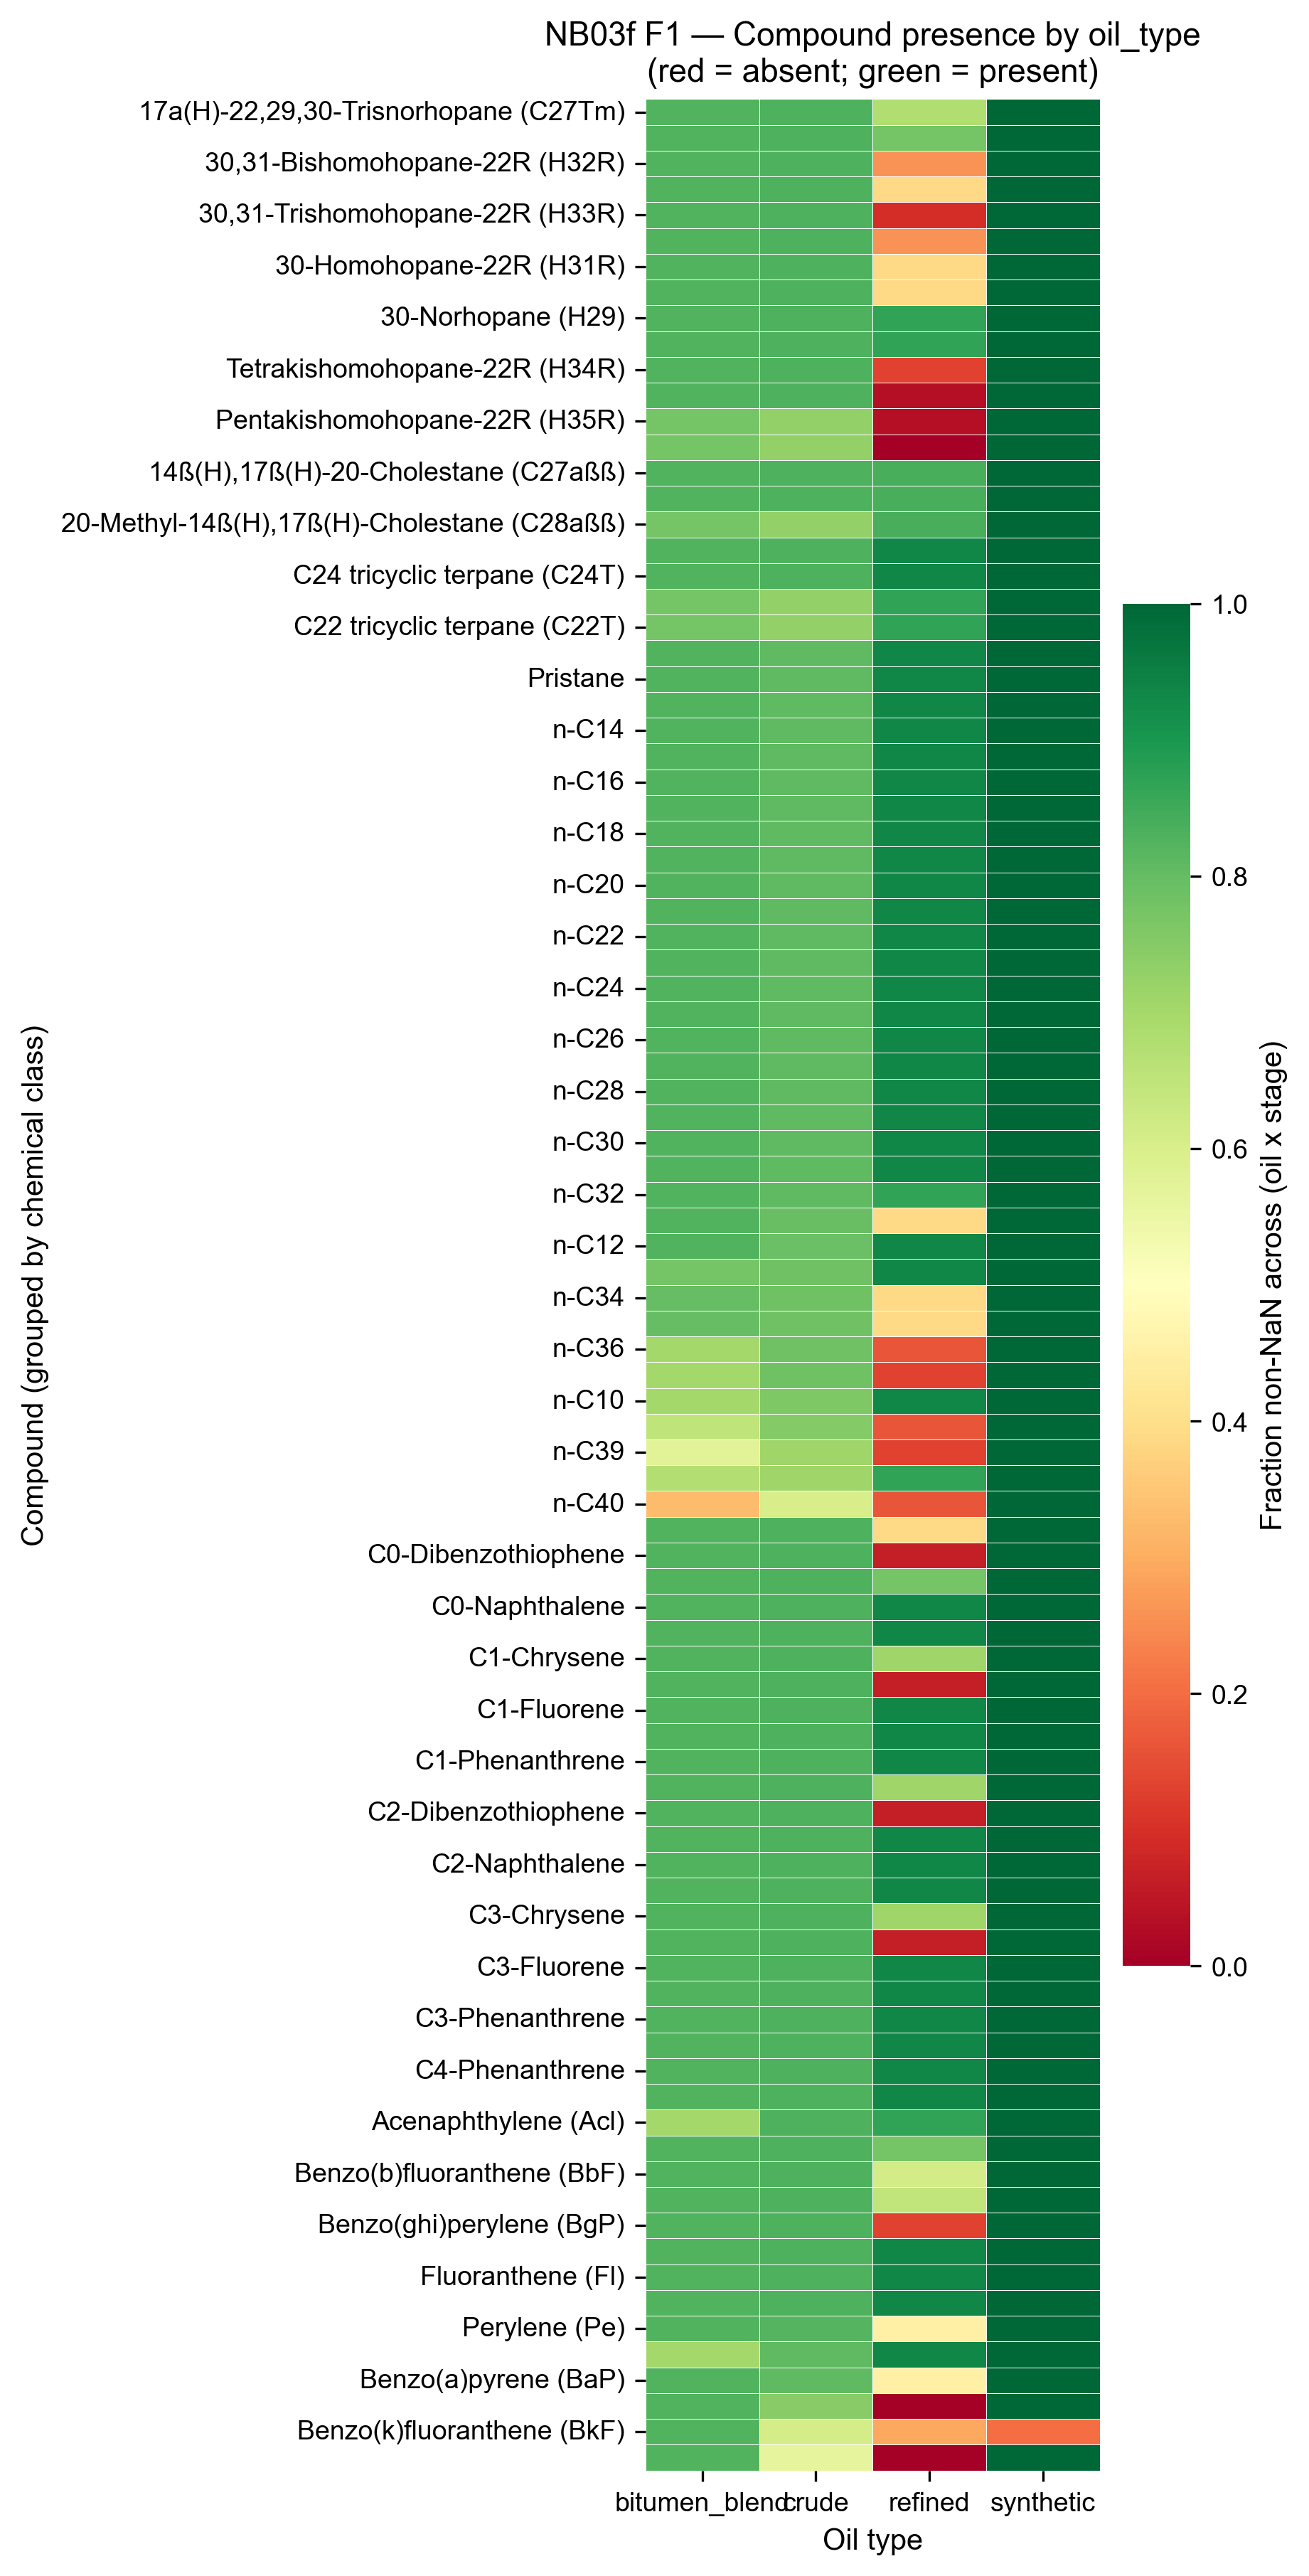

✅ F1 saved


In [7]:
# Cell S1.4 — Figure F1: compound NaN heatmap

comp_rows = profile_df[profile_df['feature_kind'] == 'compound'].copy()
comp_rows['label'] = comp_rows['feature_name'].map(abbrev)
comp_rows = comp_rows.sort_values(
    ['feature_group', 'pres_crude'], ascending=[True, False]
)
pres_cols = [c for c in comp_rows.columns if c.startswith('pres_') and c not in ('pres_max', 'pres_min')]
heat = comp_rows.set_index('label')[pres_cols]
heat.columns = [c.replace('pres_', '') for c in heat.columns]

fig, ax = plt.subplots(figsize=(6, max(10, 0.13 * len(comp_rows))))
sns.heatmap(
    heat, cmap='RdYlGn', vmin=0, vmax=1,
    cbar_kws={'label': 'Fraction non-NaN across (oil x stage)'},
    ax=ax, linewidths=0.2, linecolor='white'
)
ax.set_title('NB03f F1 — Compound presence by oil_type\n'
             '(red = absent; green = present)')
ax.set_xlabel('Oil type')
ax.set_ylabel('Compound (grouped by chemical class)')
fig.savefig(FIG_DIR / 'F1_feature_nan_heatmap.png', bbox_inches='tight')
display(Image(filename=str(FIG_DIR / 'F1_feature_nan_heatmap.png')))
plt.close(fig)
print('✅ F1 saved')

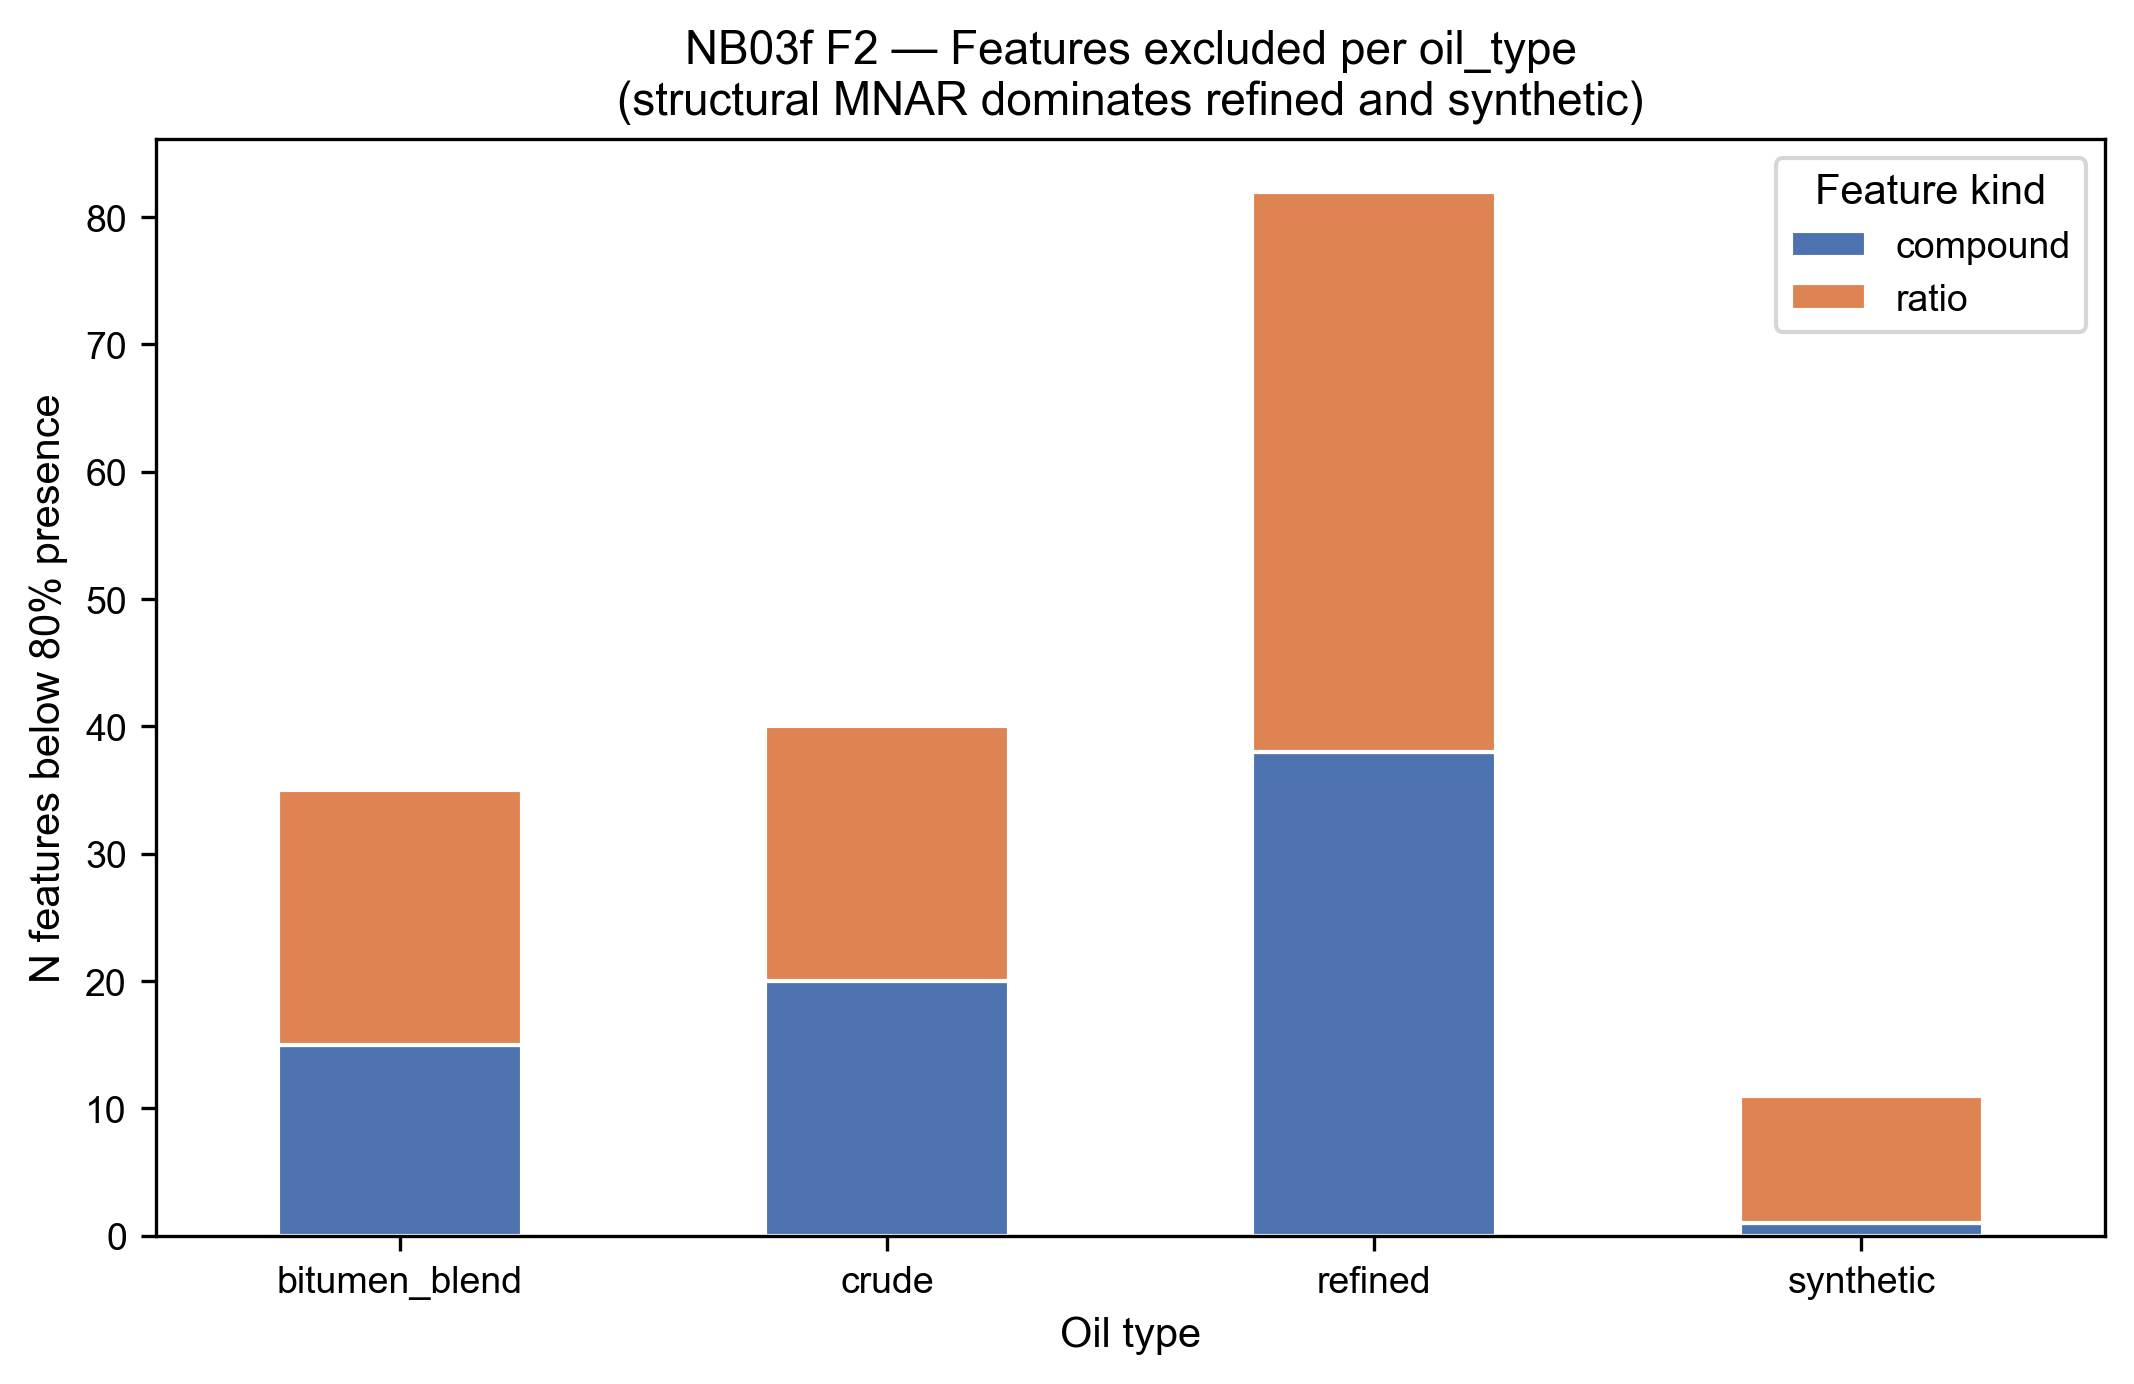

✅ F2 saved


In [8]:
# Cell S1.5 — Figure F2: NaN by oil_type bar chart

excluded = {}
for t in OIL_TYPES:
    col = f'pres_{t}'
    if col in profile_df.columns:
        excluded[t] = profile_df[profile_df[col] < THRESHOLD_PRESENT]

counts = pd.DataFrame({
    t: df['feature_kind'].value_counts().reindex(['compound', 'ratio'], fill_value=0)
    for t, df in excluded.items()
})

fig, ax = plt.subplots(figsize=(7, 4.5))
counts.T.plot(kind='bar', stacked=True, ax=ax,
              color=['#4c72b0', '#dd8452'], edgecolor='white')
ax.set_ylabel(f'N features below {int(THRESHOLD_PRESENT*100)}% presence')
ax.set_xlabel('Oil type')
ax.set_title('NB03f F2 — Features excluded per oil_type\n'
             '(structural MNAR dominates refined and synthetic)')
ax.legend(title='Feature kind')
plt.xticks(rotation=0)
fig.savefig(FIG_DIR / 'F2_nan_by_oiltype.png', bbox_inches='tight')
display(Image(filename=str(FIG_DIR / 'F2_nan_by_oiltype.png')))
plt.close(fig)
print('✅ F2 saved')

---
## Section 2 — Outlier Analysis (Decision 2)

**No winsorization.** Report skewness and kurtosis descriptively. Flag features with
`|skew| > 5` for documentation, but do not transform. XGBoost is invariant to monotone
transformations; trimming extreme values would alter the Wilcoxon signal.


Total features with skew/kurt computed: 200
Flagged |skew| > 5 (no transformation applied): 28

Top 10 high-skew features (flagged, NOT winsorized):
                    feature     kind   n  skewness   kurtosis
                C3Phe_C4Phe    ratio 210 13.536138 188.906288
Indeno(1,2,3-cd)pyrene (IP) compound 142 10.535110 117.573104
                LMW_HMW_alk    ratio 206  8.923725  83.775811
                C0Phe_C4Phe    ratio 210  8.444948  82.479233
                C2Phe_C4Phe    ratio 210  8.143625  85.930831
                C3BNT_C4BNT    ratio  65  7.869003  59.953616
                C2BNT_C4BNT    ratio  65  7.840949  59.663840
                C1BNT_C4BNT    ratio  65  7.786127  59.095815
                C0BNT_C4BNT    ratio  65  7.769590  58.925827
                  nC12_nC24    ratio 203  7.759764  68.411943


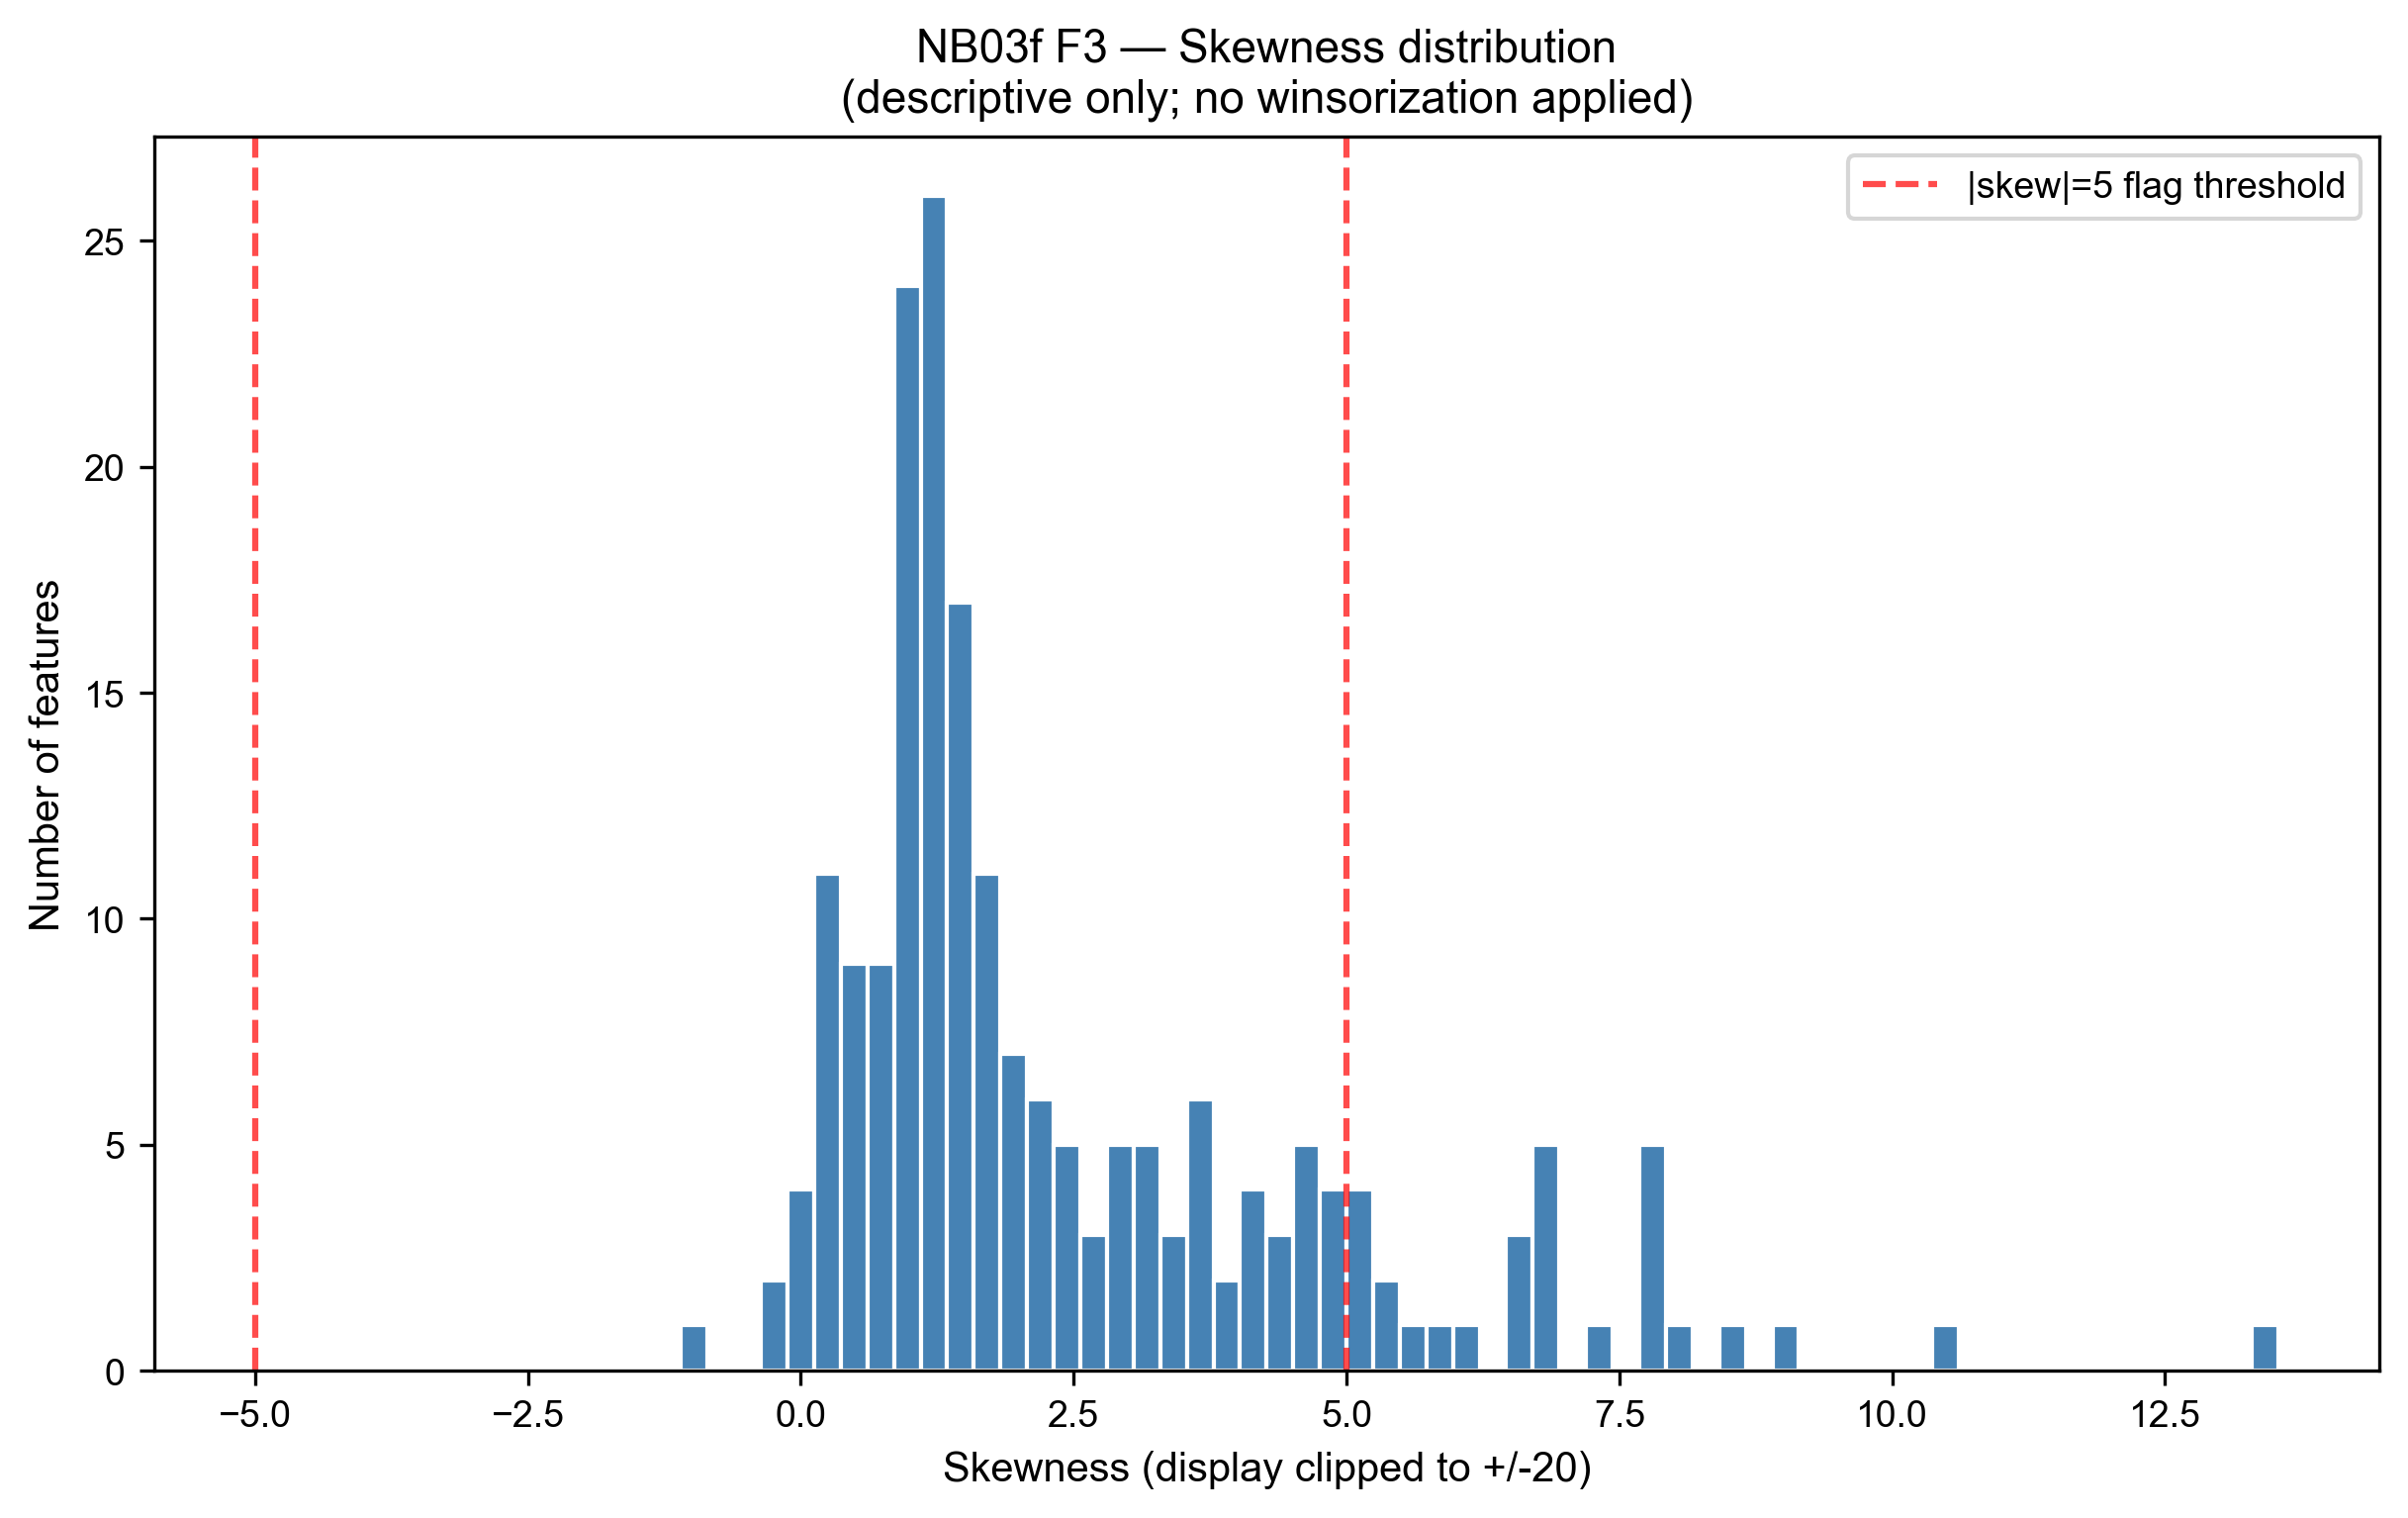

✅ F3 saved


In [9]:
# Cell S2.1 — Compute skewness and kurtosis + Figure F3

comp_wide = meas.pivot_table(
    index=['oil_name', 'stage_code'],
    columns='compound_name',
    values='value_imputed'
)
rat_wide = ratios.pivot_table(
    index=['oil_name', 'stage_code'],
    columns='ratio_name',
    values='value'
)

def feature_stats(wide, kind):
    rows = []
    for col in wide.columns:
        vals = wide[col].dropna()
        if len(vals) < 10 or vals.std(ddof=0) == 0:
            continue
        rows.append({
            'feature': col,
            'kind': kind,
            'n': int(len(vals)),
            'skewness': float(sp_stats.skew(vals, nan_policy='omit')),
            'kurtosis': float(sp_stats.kurtosis(vals, nan_policy='omit', fisher=True)),
        })
    return pd.DataFrame(rows)

stats_df = pd.concat([
    feature_stats(comp_wide, 'compound'),
    feature_stats(rat_wide,  'ratio'),
], ignore_index=True)

high_skew = stats_df[stats_df['skewness'].abs() > 5].copy()
high_skew = high_skew.sort_values('skewness', key=abs, ascending=False)

print(f'Total features with skew/kurt computed: {len(stats_df)}')
print(f'Flagged |skew| > 5 (no transformation applied): {len(high_skew)}')
print('\nTop 10 high-skew features (flagged, NOT winsorized):')
print(high_skew.head(10).to_string(index=False))

# F3 — skewness histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(stats_df['skewness'].clip(-20, 20), bins=60,
        color='steelblue', edgecolor='white')
ax.axvline( 5, ls='--', color='red', alpha=0.7, label='|skew|=5 flag threshold')
ax.axvline(-5, ls='--', color='red', alpha=0.7)
ax.set_xlabel('Skewness (display clipped to +/-20)')
ax.set_ylabel('Number of features')
ax.set_title('NB03f F3 — Skewness distribution\n'
             '(descriptive only; no winsorization applied)')
ax.legend()
fig.savefig(FIG_DIR / 'F3_skewness_histogram.png', bbox_inches='tight')
display(Image(filename=str(FIG_DIR / 'F3_skewness_histogram.png')))
plt.close(fig)
print('✅ F3 saved')

---
## Section 3 — Log-transform Scope (Decision 3)

`log1p` transform applied ONLY to PCA/linear configurations (C4, C4b, Ridge).
Tree-based configs (C1, C2, C3, C5, C6, C8, C2i, C4c) are scale-invariant.
Applied per-fold inside the LOOO loop in NB04.

In [10]:
# Cell S3.1 — Declare log-transform scope

log_transform_policy = {
    'applies_to':        ['C4', 'C4b', 'Ridge'],
    'does_not_apply_to': ['C1', 'C2', 'C3', 'C5', 'C6', 'C8', 'C2i', 'C4c'],
    'transformation':    'np.log1p(np.clip(x, a_min=0, a_max=None))',
    'rationale': (
        'PCA and Ridge are variance/distance-based. log1p stabilizes '
        'variance across compounds spanning 4+ orders of magnitude. '
        'Tree-based models are invariant to monotone transformations.'
    ),
    'order_of_operations': (
        'PER-FOLD inside LOOO: '
        '1) median imputation of train fold NaN -> '
        '2) log1p transform (only for C4/C4b/Ridge) -> '
        '3) z-score standardization (fit on train, transform test).'
    ),
    'where_applied': 'NB04 LOOO loop — NEVER in NB03f',
}
print(json.dumps(log_transform_policy, indent=2))

{
  "applies_to": [
    "C4",
    "C4b",
    "Ridge"
  ],
  "does_not_apply_to": [
    "C1",
    "C2",
    "C3",
    "C5",
    "C6",
    "C8",
    "C2i",
    "C4c"
  ],
  "transformation": "np.log1p(np.clip(x, a_min=0, a_max=None))",
  "rationale": "PCA and Ridge are variance/distance-based. log1p stabilizes variance across compounds spanning 4+ orders of magnitude. Tree-based models are invariant to monotone transformations.",
  "order_of_operations": "PER-FOLD inside LOOO: 1) median imputation of train fold NaN -> 2) log1p transform (only for C4/C4b/Ridge) -> 3) z-score standardization (fit on train, transform test).",
  "where_applied": "NB04 LOOO loop \u2014 NEVER in NB03f"
}


---
## Section 4 — NaN Imputation per-config (Decision 4)

NaN handling is configuration-dependent, applied per-fold inside the LOOO loop.
NB03f does NOT impute any value.

- **XGBoost native sparsity-aware split** (C1, C2, C3, C5, C8, C2i, C4c): handles NaN internally.
- **sklearn RandomForest** (C6): `np.nanmedian(X_train_fold)` per-fold.
- **PCA / Ridge** (C4, C4b, Ridge): `np.nanmedian(X_train_fold)` per-fold.

In [11]:
# Cell S4.1 — Declare NaN imputation per-config

nan_imputation_policy = {
    'native_sparsity_aware': {
        'configs': ['C1', 'C2', 'C3', 'C5', 'C8', 'C2i', 'C4c'],
        'implementation': 'XGBoost default branch routing — no imputation',
        'imputation_value': None,
        'scope': 'per-fold (no imputation needed)',
    },
    'median_per_fold': {
        'configs': ['C4', 'C4b', 'C6', 'Ridge'],
        'implementation': 'np.nanmedian of TRAINING fold columns only',
        'imputation_value': 'np.nanmedian(X_train_fold[:, col])',
        'scope': 'PER-FOLD inside LOOO; global imputation is FORBIDDEN',
    },
    'forbidden_methods': [
        'KNN imputation (leaks compositional neighborhood signal)',
        'MICE / IterativeImputer (n too small, MAR violated)',
        'global median (test fold contaminates train statistics)',
        'LOD/2 (no LOD reported by ECCC — would invent threshold)',
        'has_X binary indicator + imputed value (redundant with native NaN)',
    ],
    'reference': 'GUARDRAILS §3b.2 and §4.4 (Optuna nested CV)',
}
print(json.dumps(nan_imputation_policy, indent=2))

# Invariant: NB03f does not touch measurements
n_null_before = cur.execute(
    'SELECT COUNT(*) FROM measurements WHERE value_imputed IS NULL'
).fetchone()[0]
assert n_null_before > 500, (
    f'measurements NaN count changed suspiciously ({n_null_before}). '
    f'NB03f must not mutate measurements.'
)
print(f'\n✅ measurements.value_imputed NULLs preserved: {n_null_before} '
      f'(NB03f does not impute)')

{
  "native_sparsity_aware": {
    "configs": [
      "C1",
      "C2",
      "C3",
      "C5",
      "C8",
      "C2i",
      "C4c"
    ],
    "implementation": "XGBoost default branch routing \u2014 no imputation",
    "imputation_value": null,
    "scope": "per-fold (no imputation needed)"
  },
  "median_per_fold": {
    "configs": [
      "C4",
      "C4b",
      "C6",
      "Ridge"
    ],
    "implementation": "np.nanmedian of TRAINING fold columns only",
    "imputation_value": "np.nanmedian(X_train_fold[:, col])",
    "scope": "PER-FOLD inside LOOO; global imputation is FORBIDDEN"
  },
  "forbidden_methods": [
    "KNN imputation (leaks compositional neighborhood signal)",
    "MICE / IterativeImputer (n too small, MAR violated)",
    "global median (test fold contaminates train statistics)",
    "LOD/2 (no LOD reported by ECCC \u2014 would invent threshold)",
    "has_X binary indicator + imputed value (redundant with native NaN)"
  ],
  "reference": "GUARDRAILS \u00a73b.2 and 

---
## Section 5 — Scaling Scope (Decision 5)

Z-score standardization via `StandardScaler` applies ONLY to C4, C4b, Ridge.
Fit on training fold, transform on training + test fold. Applied per-fold inside LOOO.

In [12]:
# Cell S5.1 — Declare scaling scope

scaling_policy = {
    'zscore_per_fold': {
        'configs': ['C4', 'C4b', 'Ridge'],
        'implementation': 'sklearn.preprocessing.StandardScaler',
        'fit_on':       'training fold only',
        'transform_on': 'training fold and test fold (transform step)',
        'scope': 'PER-FOLD inside LOOO',
        'pipeline_order': (
            '1) median imputation (Decision 4) -> '
            '2) log1p (Decision 3, PCA/Ridge only) -> '
            '3) z-score (this step)'
        ),
    },
    'no_scaling': {
        'configs': ['C1', 'C2', 'C3', 'C5', 'C6', 'C8', 'C2i', 'C4c'],
        'rationale': 'Tree-based models are invariant to feature scaling',
    },
}
print(json.dumps(scaling_policy, indent=2))

{
  "zscore_per_fold": {
    "configs": [
      "C4",
      "C4b",
      "Ridge"
    ],
    "implementation": "sklearn.preprocessing.StandardScaler",
    "fit_on": "training fold only",
    "transform_on": "training fold and test fold (transform step)",
    "scope": "PER-FOLD inside LOOO",
    "pipeline_order": "1) median imputation (Decision 4) -> 2) log1p (Decision 3, PCA/Ridge only) -> 3) z-score (this step)"
  },
  "no_scaling": {
    "configs": [
      "C1",
      "C2",
      "C3",
      "C5",
      "C6",
      "C8",
      "C2i",
      "C4c"
    ],
    "rationale": "Tree-based models are invariant to feature scaling"
  }
}


---
## Section 6 — Log-ratio Redundancy (Decision 6)

For each diagnostic ratio `R` that has a log counterpart `R_log` in `diagnostic_ratios`,
compute Spearman rho. Resolution rule:
- If `|rho| > 0.98` AND `min(R) >= 0.05` → keep **linear** (interpretability)
- If `|rho| > 0.98` AND `min(R) < 0.05` → keep **log** (numerical stability)
- If `|rho| <= 0.98` → keep both

**Note on current DB state:** NB02 stores pre-computed `log_ratio_{name}` in
`sample_properties` (16,876 records), NOT in `diagnostic_ratios`. These are not
consumed by the ML pipeline — Decision 3 (`log1p` per-fold for PCA/Ridge) makes
them redundant. Spearman rho between R and ln(R) is always ≈1.0 (log is monotonic,
rho is rank-based), so the analysis would be trivially confirmatory. Section 6 is
therefore a **no-op** in the current schema; the table and figure are preserved as
placeholders for future NB02 revisions that might add log-ratios to `diagnostic_ratios`.

In [13]:
# Cell S6.1 — Compute redundancy per linear/log pair

all_ratio_names = set(ratios['ratio_name'].unique())
lin_log_pairs = [
    (rn, rn + '_log')
    for rn in all_ratio_names
    if not rn.endswith('_log') and (rn + '_log') in all_ratio_names
]
print(f'Linear/log ratio pairs detected: {len(lin_log_pairs)}')

redund_rows = []
for lin, log_name in lin_log_pairs:
    lin_vals = (ratios[ratios['ratio_name'] == lin]
                .set_index(['oil_name', 'stage_code'])['value'])
    log_vals = (ratios[ratios['ratio_name'] == log_name]
                .set_index(['oil_name', 'stage_code'])['value'])
    joined = pd.concat(
        [lin_vals.rename('lin'), log_vals.rename('log')], axis=1
    ).dropna()
    if len(joined) < 20:
        continue
    rho, p = sp_stats.spearmanr(joined['lin'], joined['log'])
    min_lin = float(joined['lin'].min())

    if abs(rho) > 0.98:
        if min_lin < 0.05:
            keep, drop_name = log_name, lin
            reason = 'rho > 0.98 and min(linear) < 0.05 -> keep log (numerical stability)'
        else:
            keep, drop_name = lin, log_name
            reason = 'rho > 0.98 and min(linear) >= 0.05 -> keep linear (interpretability)'
    else:
        keep, drop_name = 'both', None
        reason = f'|rho|={abs(rho):.3f} <= 0.98 -> both carry distinct information'

    redund_rows.append({
        'ratio_linear': lin, 'ratio_log': log_name,
        'spearman_rho': float(rho), 'p_value': float(p),
        'n': int(len(joined)), 'min_linear': min_lin,
        'keep': keep, 'drop_name': drop_name, 'reason': reason,
    })

redund_df = pd.DataFrame(redund_rows)
if len(redund_df) > 0:
    print(f'Pairs analyzed: {len(redund_df)}')
    print(f'  keep linear, drop log:    {(redund_df["drop_name"]==redund_df["ratio_log"]).sum()}')
    print(f'  keep log, drop linear:    {(redund_df["drop_name"]==redund_df["ratio_linear"]).sum()}')
    print(f'  keep both (rho <= 0.98):  {(redund_df["keep"]=="both").sum()}')
else:
    print('No _log ratio pairs found in database — Section 6 is a no-op.')
    print('log_ratio_redundancy table will be created empty (acceptable).')

Linear/log ratio pairs detected: 0
No _log ratio pairs found in database — Section 6 is a no-op.
log_ratio_redundancy table will be created empty (acceptable).


In [14]:
# Cell S6.1b — Persist log_ratio_redundancy

cur.executescript("""
CREATE TABLE IF NOT EXISTS log_ratio_redundancy (
    pair_id       INTEGER PRIMARY KEY AUTOINCREMENT,
    ratio_linear  TEXT NOT NULL,
    ratio_log     TEXT NOT NULL,
    spearman_rho  REAL,
    p_value       REAL,
    n             INTEGER,
    min_linear    REAL,
    keep          TEXT,
    drop_name     TEXT,
    reason        TEXT,
    created_at    TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    UNIQUE(ratio_linear, ratio_log)
);
""")
cur.execute('DELETE FROM log_ratio_redundancy')

if len(redund_df) > 0:
    cur.executemany("""
    INSERT INTO log_ratio_redundancy
    (ratio_linear, ratio_log, spearman_rho, p_value, n, min_linear,
     keep, drop_name, reason)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, redund_df[['ratio_linear', 'ratio_log', 'spearman_rho', 'p_value',
                     'n', 'min_linear', 'keep', 'drop_name', 'reason']]
         .itertuples(index=False, name=None))

conn.commit()
print(f'✅ log_ratio_redundancy: {len(redund_df)} rows persisted')

✅ log_ratio_redundancy: 0 rows persisted


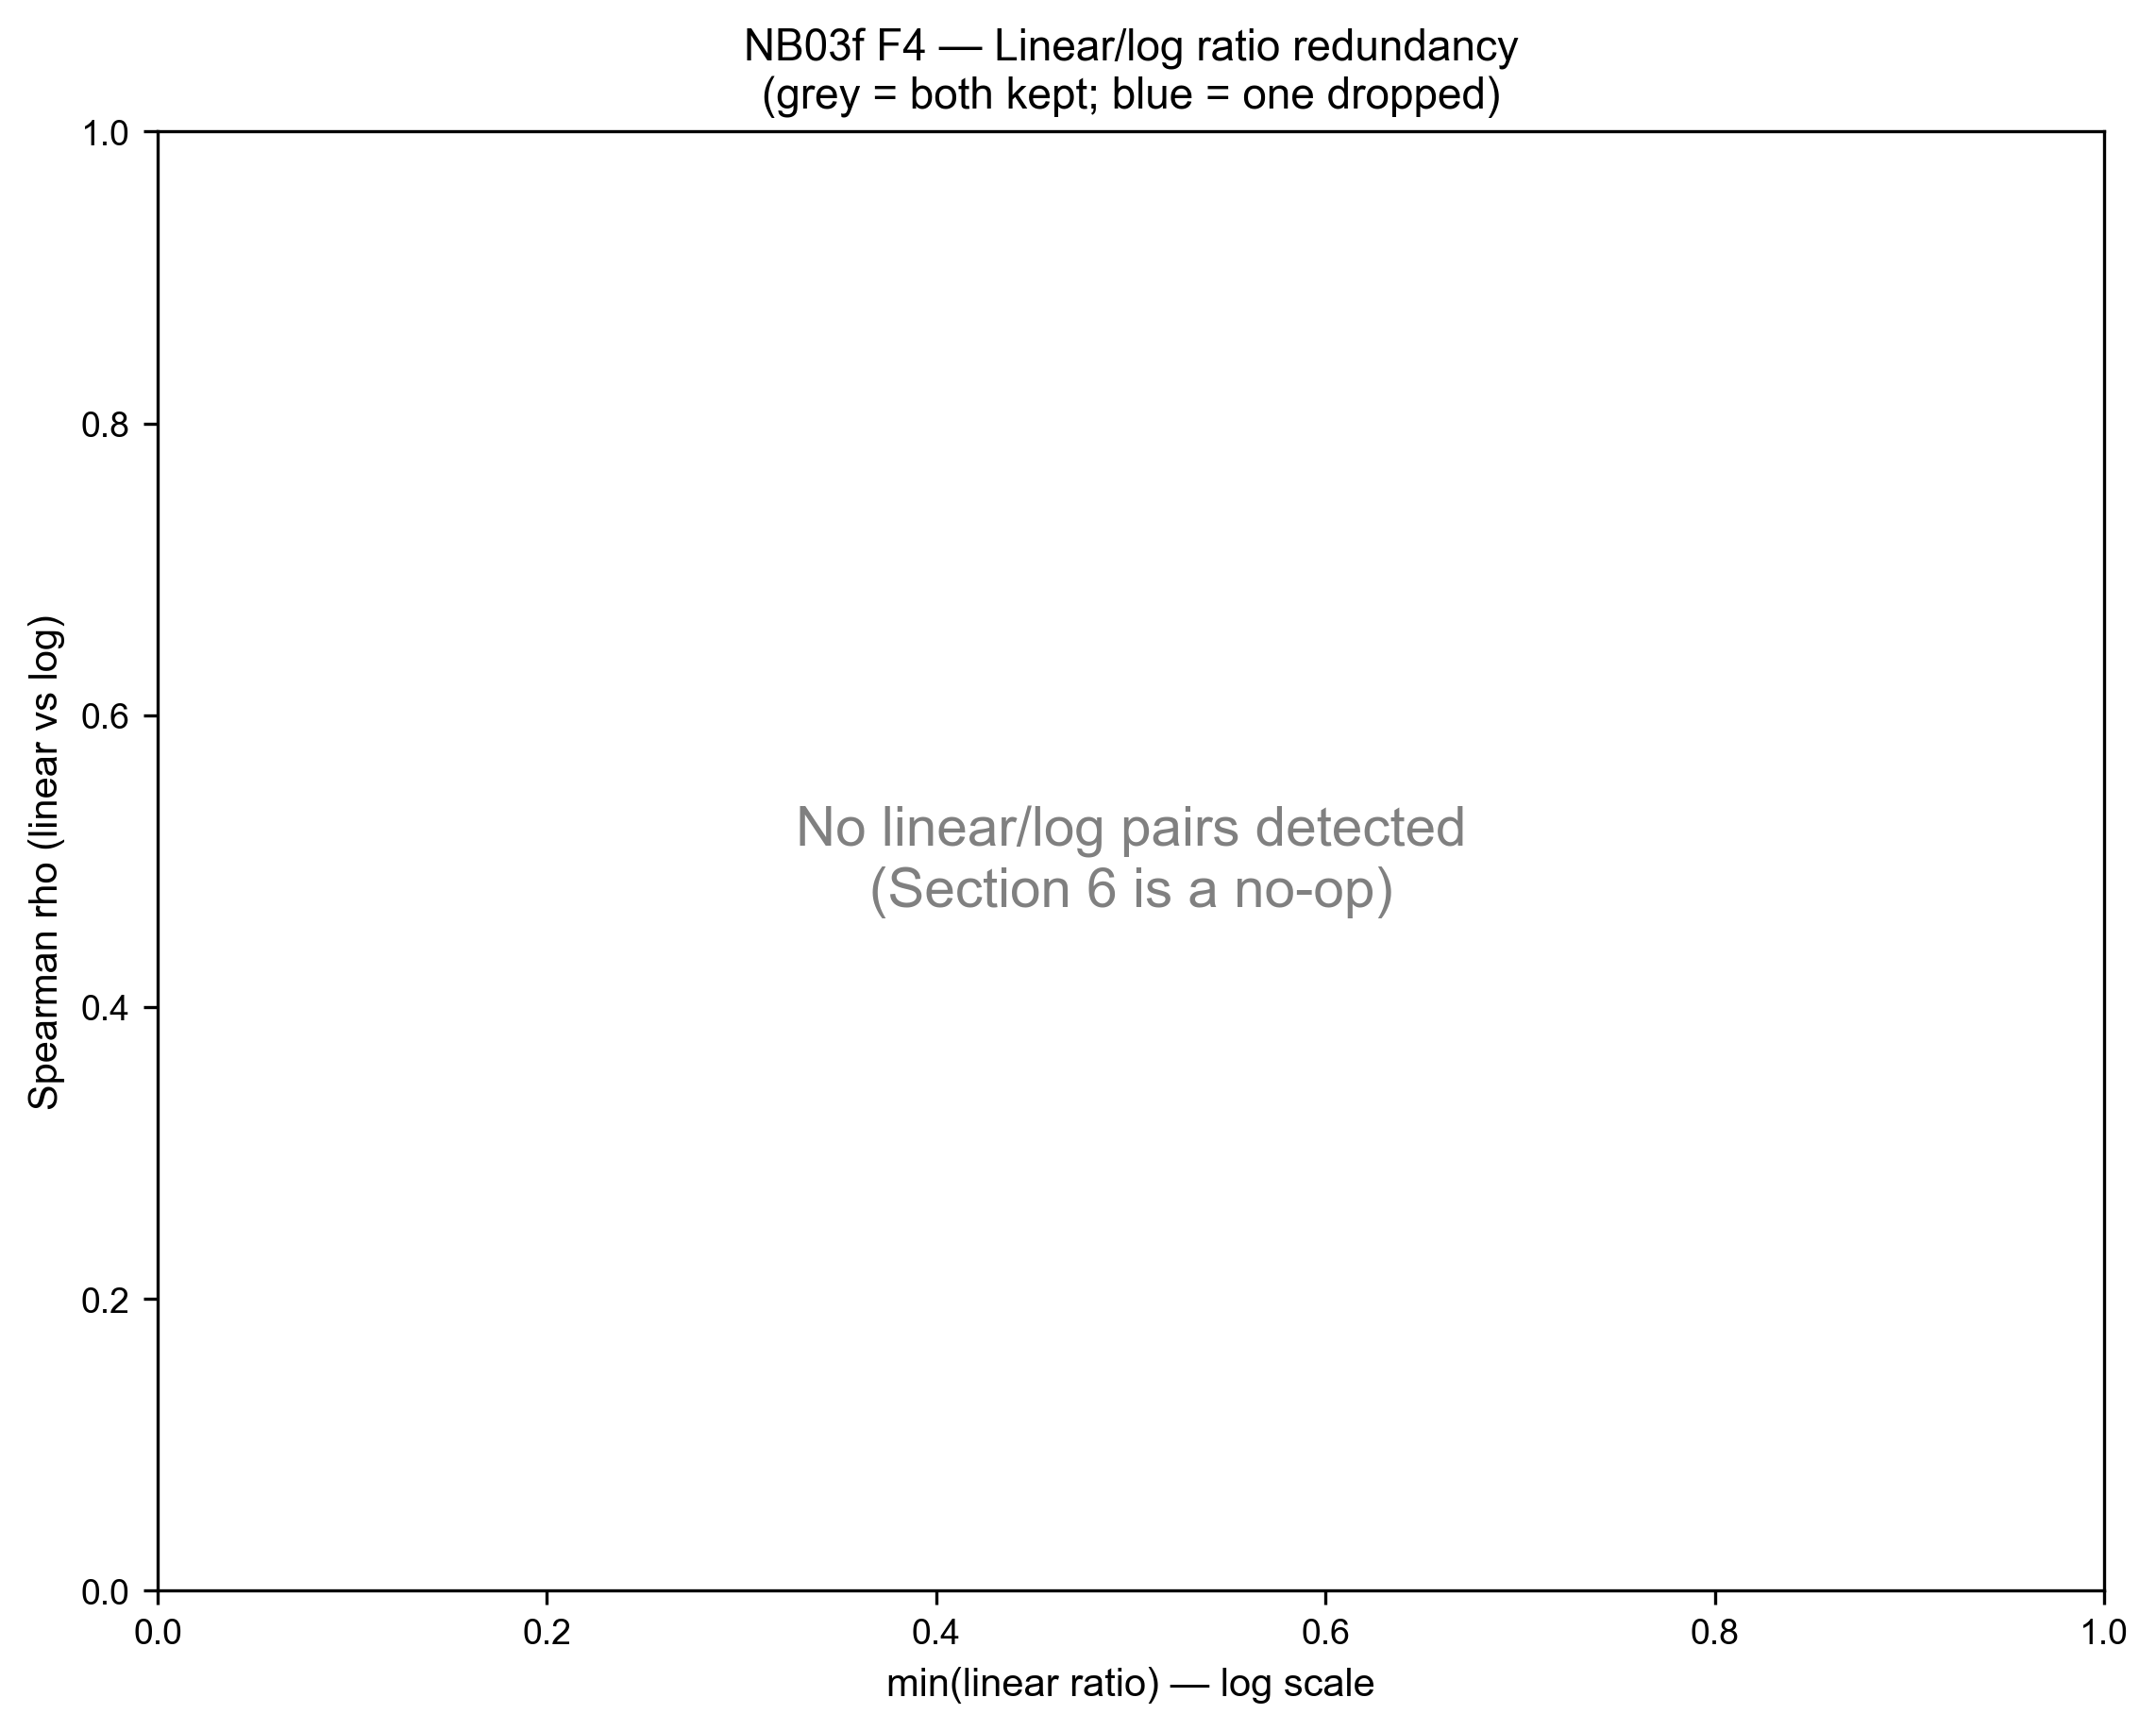

✅ F4 saved


In [15]:
# Cell S6.2 — Figure F4: Spearman rho vs min(linear)

fig, ax = plt.subplots(figsize=(7.5, 6))

if len(redund_df) > 0:
    colors = ['#888888' if k == 'both' else '#4c72b0' for k in redund_df['keep']]
    ax.scatter(
        redund_df['min_linear'].clip(lower=1e-6),
        redund_df['spearman_rho'],
        c=colors, edgecolor='white', s=65, alpha=0.85
    )
    ax.axhline( 0.98, ls='--', color='red', alpha=0.6, label='|rho|=0.98 (redundancy cutoff)')
    ax.axhline(-0.98, ls='--', color='red', alpha=0.6)
    ax.axvline(0.05, ls='--', color='orange', alpha=0.6, label='min=0.05 (stability cutoff)')
    ax.set_xscale('log')
    ax.legend(loc='lower left')
else:
    ax.text(0.5, 0.5, 'No linear/log pairs detected\n(Section 6 is a no-op)',
            ha='center', va='center', transform=ax.transAxes, fontsize=14, color='gray')

ax.set_xlabel('min(linear ratio) — log scale')
ax.set_ylabel('Spearman rho (linear vs log)')
ax.set_title('NB03f F4 — Linear/log ratio redundancy\n'
             '(grey = both kept; blue = one dropped)')
fig.savefig(FIG_DIR / 'F4_logratio_redundancy_scatter.png', bbox_inches='tight')
display(Image(filename=str(FIG_DIR / 'F4_logratio_redundancy_scatter.png')))
plt.close(fig)
print('✅ F4 saved')

---
## Section 7 — TPH Normalization Decision (Decision 7)

Keep D17 mass-loss correction (BP<270C compounds only). Do NOT apply TPH-normalization.

In [16]:
# Cell S7.1 — Declare TPH-norm decision

tph_norm_decision = {
    'applied': False,
    'keep':    'D17 mass-loss correction (BP<270C, applied in NB02)',
    'rationale': (
        'TPH-normalization (C_i / sum_C) would remove the concentration effect '
        'on recalcitrant compounds (H30, chrysenes, C29+ n-alkanes). '
        'That concentration effect is the signature of evaporative '
        'weathering in the heavy fraction — normalizing destroys it.'
    ),
    'risk_if_applied': (
        'Loss of evaporative signal in hopanes, chrysenes, heavy alkanes '
        '-> MAE likely increases, Tier 3 vs Tier 1 contrast collapses.'
    ),
    'reference': 'D17 (NB02 mass_loss_correction); GUARDRAILS §3 mass-loss',
}
print(json.dumps(tph_norm_decision, indent=2))

{
  "applied": false,
  "keep": "D17 mass-loss correction (BP<270C, applied in NB02)",
  "rationale": "TPH-normalization (C_i / sum_C) would remove the concentration effect on recalcitrant compounds (H30, chrysenes, C29+ n-alkanes). That concentration effect is the signature of evaporative weathering in the heavy fraction \u2014 normalizing destroys it.",
  "risk_if_applied": "Loss of evaporative signal in hopanes, chrysenes, heavy alkanes -> MAE likely increases, Tier 3 vs Tier 1 contrast collapses.",
  "reference": "D17 (NB02 mass_loss_correction); GUARDRAILS \u00a73 mass-loss"
}


---
## Section 8 — Missingness Binary Feature (Decision 8)

Do NOT create `has_X` binary indicators. XGBoost native sparsity-aware split is
mathematically equivalent.

In [17]:
# Cell S8.1 — Declare missingness policy

missingness_policy = {
    'create_binary_indicators': False,
    'rationale': (
        'XGBoost native sparsity-aware split treats NaN as a learnable '
        'default branch. For a feature X and a split threshold theta, '
        '"X<theta | NaN->default" is mathematically equivalent to '
        '"X<theta | has_X=0->default". Creating explicit has_X features is '
        'redundant information and inflates feature count (affects SHAP '
        'redistribution, DP41).'
    ),
    'revisit_condition': (
        'If NB06 SHAP reveals missingness patterns drive top-10 rankings '
        'in ways XGBoost native NaN routing cannot capture (e.g., '
        'multi-feature interactions), add has_X as a targeted patch.'
    ),
    'shap_interpretation_rule': (
        '"NaN pattern for H30 contributed to oil_type discrimination" — OK. '
        '"H30 = 0 indicates refined oil" — NOT OK (confuses MNAR with '
        'measured zero).'
    ),
    'reference': 'GUARDRAILS §3b.2 (forbidden combinations) and §3b.4 '
                 '(SHAP interpretation for MNAR)',
}
print(json.dumps(missingness_policy, indent=2))

{
  "create_binary_indicators": false,
  "rationale": "XGBoost native sparsity-aware split treats NaN as a learnable default branch. For a feature X and a split threshold theta, \"X<theta | NaN->default\" is mathematically equivalent to \"X<theta | has_X=0->default\". Creating explicit has_X features is redundant information and inflates feature count (affects SHAP redistribution, DP41).",
  "revisit_condition": "If NB06 SHAP reveals missingness patterns drive top-10 rankings in ways XGBoost native NaN routing cannot capture (e.g., multi-feature interactions), add has_X as a targeted patch.",
  "shap_interpretation_rule": "\"NaN pattern for H30 contributed to oil_type discrimination\" \u2014 OK. \"H30 = 0 indicates refined oil\" \u2014 NOT OK (confuses MNAR with measured zero).",
  "reference": "GUARDRAILS \u00a73b.2 (forbidden combinations) and \u00a73b.4 (SHAP interpretation for MNAR)"
}


---
## Section 9 — SHAP Grouping (Decision 9)

Chemical-hierarchy groups for SHAP aggregation in NB06. These aggregate compounds
and ratios into natural thermodynamic/taxonomic hierarchies.


In [18]:
# Cell S9.1 — Define SHAP groups and persist

# Actual compound names from DB; ratio lists filtered against DB inventory
shap_groups_def = {
    'n_alk_light': {
        'compounds': [f'n-C{i}' for i in range(9, 16)],
        'ratios': sorted(set(['nC10_nC20', 'nC10_C23T', 'nC10_Ph',
                              'nC12_nC24', 'nC13_C23T', 'nC13_Ph']) & all_ratio_names),
        'bp_range_c': '151-271',
        'note': 'Near-complete depletion by W3 under 80C evaporation.',
    },
    'n_alk_medium': {
        'compounds': [f'n-C{i}' for i in range(16, 25)],
        'ratios': sorted(set(['nC17_Pr', 'nC17_H30', 'nC18_Ph', 'nC18_H30']) & all_ratio_names),
        'bp_range_c': '287-391',
        'note': 'Partial depletion, oil-type dependent.',
    },
    'n_alk_heavy': {
        'compounds': [f'n-C{i}' for i in range(25, 41)],
        'ratios': sorted(set(['LMW_HMW_alk']) & all_ratio_names),
        'bp_range_c': '400+',
        'note': 'Evaporation-resistant at 80C.',
    },
    'isoprenoids': {
        'compounds': ['Pristane', 'Phytane'],
        'ratios': sorted(set(['Pr_Ph', 'Pr_C23T', 'Pr_H30']) & all_ratio_names),
        'bp_range_c': '~300',
        'note': 'Branched alkanes; evaporation-resistant identity markers.',
    },
    'naphthalenes': {
        'compounds': [f'C{i}-Naphthalene' for i in range(5)],
        'ratios': sorted(r for r in all_ratio_names if 'Naph' in r),
        'bp_range_c': '218-285',
        'note': 'Most volatile PAHs; most entries classified Tier 1.',
    },
    'fluorenes': {
        'compounds': [f'C{i}-Fluorene' for i in range(4)],
        'ratios': sorted(r for r in all_ratio_names if 'Flu_' in r and 'Fluo' not in r),
        'bp_range_c': '295-370',
        'note': 'Intermediate-volatility alkylated PAHs.',
    },
    'phenanthrenes': {
        'compounds': [f'C{i}-Phenanthrene' for i in range(5)],
        'ratios': sorted(r for r in all_ratio_names if 'Phe' in r and 'DBT' not in r),
        'bp_range_c': '340-430',
        'note': 'Evaporation-resistant at 80C; classified Tier 3.',
    },
    'DBT': {
        'compounds': [f'C{i}-Dibenzothiophene' for i in range(4)],
        'ratios': sorted(r for r in all_ratio_names if 'DBT' in r),
        'bp_range_c': '332-430',
        'note': 'Sulfur-containing aromatics.',
    },
    'chrysenes': {
        'compounds': [f'C{i}-Chrysene' for i in range(4)],
        'ratios': sorted(r for r in all_ratio_names if 'Chr' in r),
        'bp_range_c': '448+',
        'note': 'Most recalcitrant PAHs; pure identity markers.',
    },
    'hopanes': {
        'compounds': [
            'Hopane (H30)', '30-Norhopane (H29)',
            '30-Homohopane-22S (H31S)', '30-Homohopane-22R (H31R)',
            '30,31-Bishomohopane-22S (H32S)', '30,31-Bishomohopane-22R (H32R)',
            '30,31-Trishomohopane-22S (H33S)', '30,31-Trishomohopane-22R (H33R)',
            'Tetrakishomohopane-22S (H34S)', 'Tetrakishomohopane-22R (H34R)',
            'Pentakishomohopane-22S (H35S)', 'Pentakishomohopane-22R (H35R)',
        ],
        'ratios': sorted(set(['H29_H30', 'H31S_H31R', 'H32S_H32R']) & all_ratio_names),
        'bp_range_c': '>500',
        'note': 'Tier 3 biomarkers.',
    },
    'steranes': {
        # F-NB03f-C1 (28/abr/2026): canonical ß per CHG-0006/F-NB01-C1.
        # Pre-fix used 'ss' transliteration; cascade from F-NB01-C1 silenced match.
        'compounds': [
            '14ß(H),17ß(H)-20-Cholestane (C27aßß)',
            '20-Methyl-14ß(H),17ß(H)-Cholestane (C28aßß)',
            '20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)',
        ],
        # F-NB03f-M1 (28/abr/2026): post-CHG-0007, 4 sterane ratios are canonical
        # in ratio_definitions. Mirror SSOT pattern of other groups via intersection
        # with all_ratio_names (defensive: any not in DB are silently dropped).
        'ratios': sorted(set(['C27est_C29est', 'C28est_C29est',
                              'C27est_H30', 'C29est_H30']) & all_ratio_names),
        'bp_range_c': '>500',
        'note': 'Maturity/source markers; 4 sterane ratios canonical post-CHG-0007.',
    },
    'triterpanes': {
        'compounds': [
            '17a(H)-22,29,30-Trisnorhopane (C27Tm)',
            '18a,22,29,30-trisnorneohopane (C27Ts)',
            'C21 tricyclic terpane (C21T)', 'C22 tricyclic terpane (C22T)',
            'C23 tricyclic terpane (C23T)', 'C24 tricyclic terpane (C24T)',
        ],
        'ratios': sorted(set(['Ts_Tm', 'C23T_C24T', 'C23T_H30']) & all_ratio_names),
        'bp_range_c': '>500',
        'note': 'Source indicators.',
    },
    'pah_priority': {
        'compounds': [
            'Acenaphthene (Ace)', 'Acenaphthylene (Acl)', 'Anthracene (An)',
            'Benz(a)anthracene (BaA)', 'Benzo(a)pyrene (BaP)',
            'Benzo(b)fluoranthene (BbF)', 'Benzo(e)pyrene (BeP)',
            'Benzo(ghi)perylene (BgP)', 'Benzo(k)fluoranthene (BkF)',
            'Biphenyl (Bph)', 'Dibenzo(ah)anthracene (DA)',
            'Fluoranthene (Fl)', 'Indeno(1,2,3-cd)pyrene (IP)',
            'Perylene (Pe)', 'Pyrene (Py)',
        ],
        'ratios': sorted(
            set(['LMW_HMW_PAH_5ring']) | set(r for r in all_ratio_names if 'Fluo' in r)),
        'bp_range_c': '279-500',
        'note': 'EPA priority PAHs + fluoranthenes; mixed volatility.',
    },
}

n_groups = len(shap_groups_def)
print(f'SHAP groups defined: {n_groups}')
for gname, gdef in shap_groups_def.items():
    print(f'  {gname:20s}: {len(gdef["compounds"]):3d} compounds, '
          f'{len(gdef["ratios"]):3d} ratios')

SHAP groups defined: 16
  n_alk_light         :   7 compounds,   6 ratios
  n_alk_medium        :   9 compounds,   4 ratios
  n_alk_heavy         :  16 compounds,   1 ratios
  isoprenoids         :   2 compounds,   3 ratios
  naphthalenes        :   5 compounds,  14 ratios
  fluorenes           :   4 compounds,   6 ratios
  phenanthrenes       :   5 compounds,  15 ratios
  DBT                 :   4 compounds,  17 ratios
  chrysenes           :   4 compounds,   7 ratios
  hopanes             :  12 compounds,   3 ratios
  steranes            :   3 compounds,   4 ratios
  triterpanes         :   6 compounds,   3 ratios
  pah_priority        :  15 compounds,  11 ratios
  ratios_tier1        :   0 compounds,  24 ratios
  ratios_tier2        :   0 compounds,   9 ratios
  ratios_tier3        :   0 compounds,  55 ratios


In [19]:
# Cell S9.1b — Persist shap_feature_groups

cur.executescript("""
CREATE TABLE IF NOT EXISTS shap_feature_groups (
    group_name      TEXT PRIMARY KEY,
    n_compounds     INTEGER,
    n_ratios        INTEGER,
    bp_range_c      TEXT,
    note            TEXT,
    compounds_json  TEXT,
    ratios_json     TEXT,
    created_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
""")
cur.execute('DELETE FROM shap_feature_groups')

group_records = [
    (gname,
     len(gdef['compounds']),
     len(gdef['ratios']),
     gdef['bp_range_c'],
     gdef['note'],
     json.dumps(gdef['compounds']),
     json.dumps(gdef['ratios']))
    for gname, gdef in shap_groups_def.items()
]
cur.executemany("""
INSERT INTO shap_feature_groups
(group_name, n_compounds, n_ratios, bp_range_c, note, compounds_json, ratios_json)
VALUES (?, ?, ?, ?, ?, ?, ?)
""", group_records)
conn.commit()

n_groups_db = cur.execute('SELECT COUNT(*) FROM shap_feature_groups').fetchone()[0]
assert n_groups_db == n_groups, f'Expected {n_groups} SHAP groups, got {n_groups_db}'
print(f'✅ shap_feature_groups persisted: {n_groups_db} groups')


✅ shap_feature_groups persisted: 16 groups
  Tier 1: 24 ratios
  Tier 2: 9 ratios
  Tier 3: 55 ratios


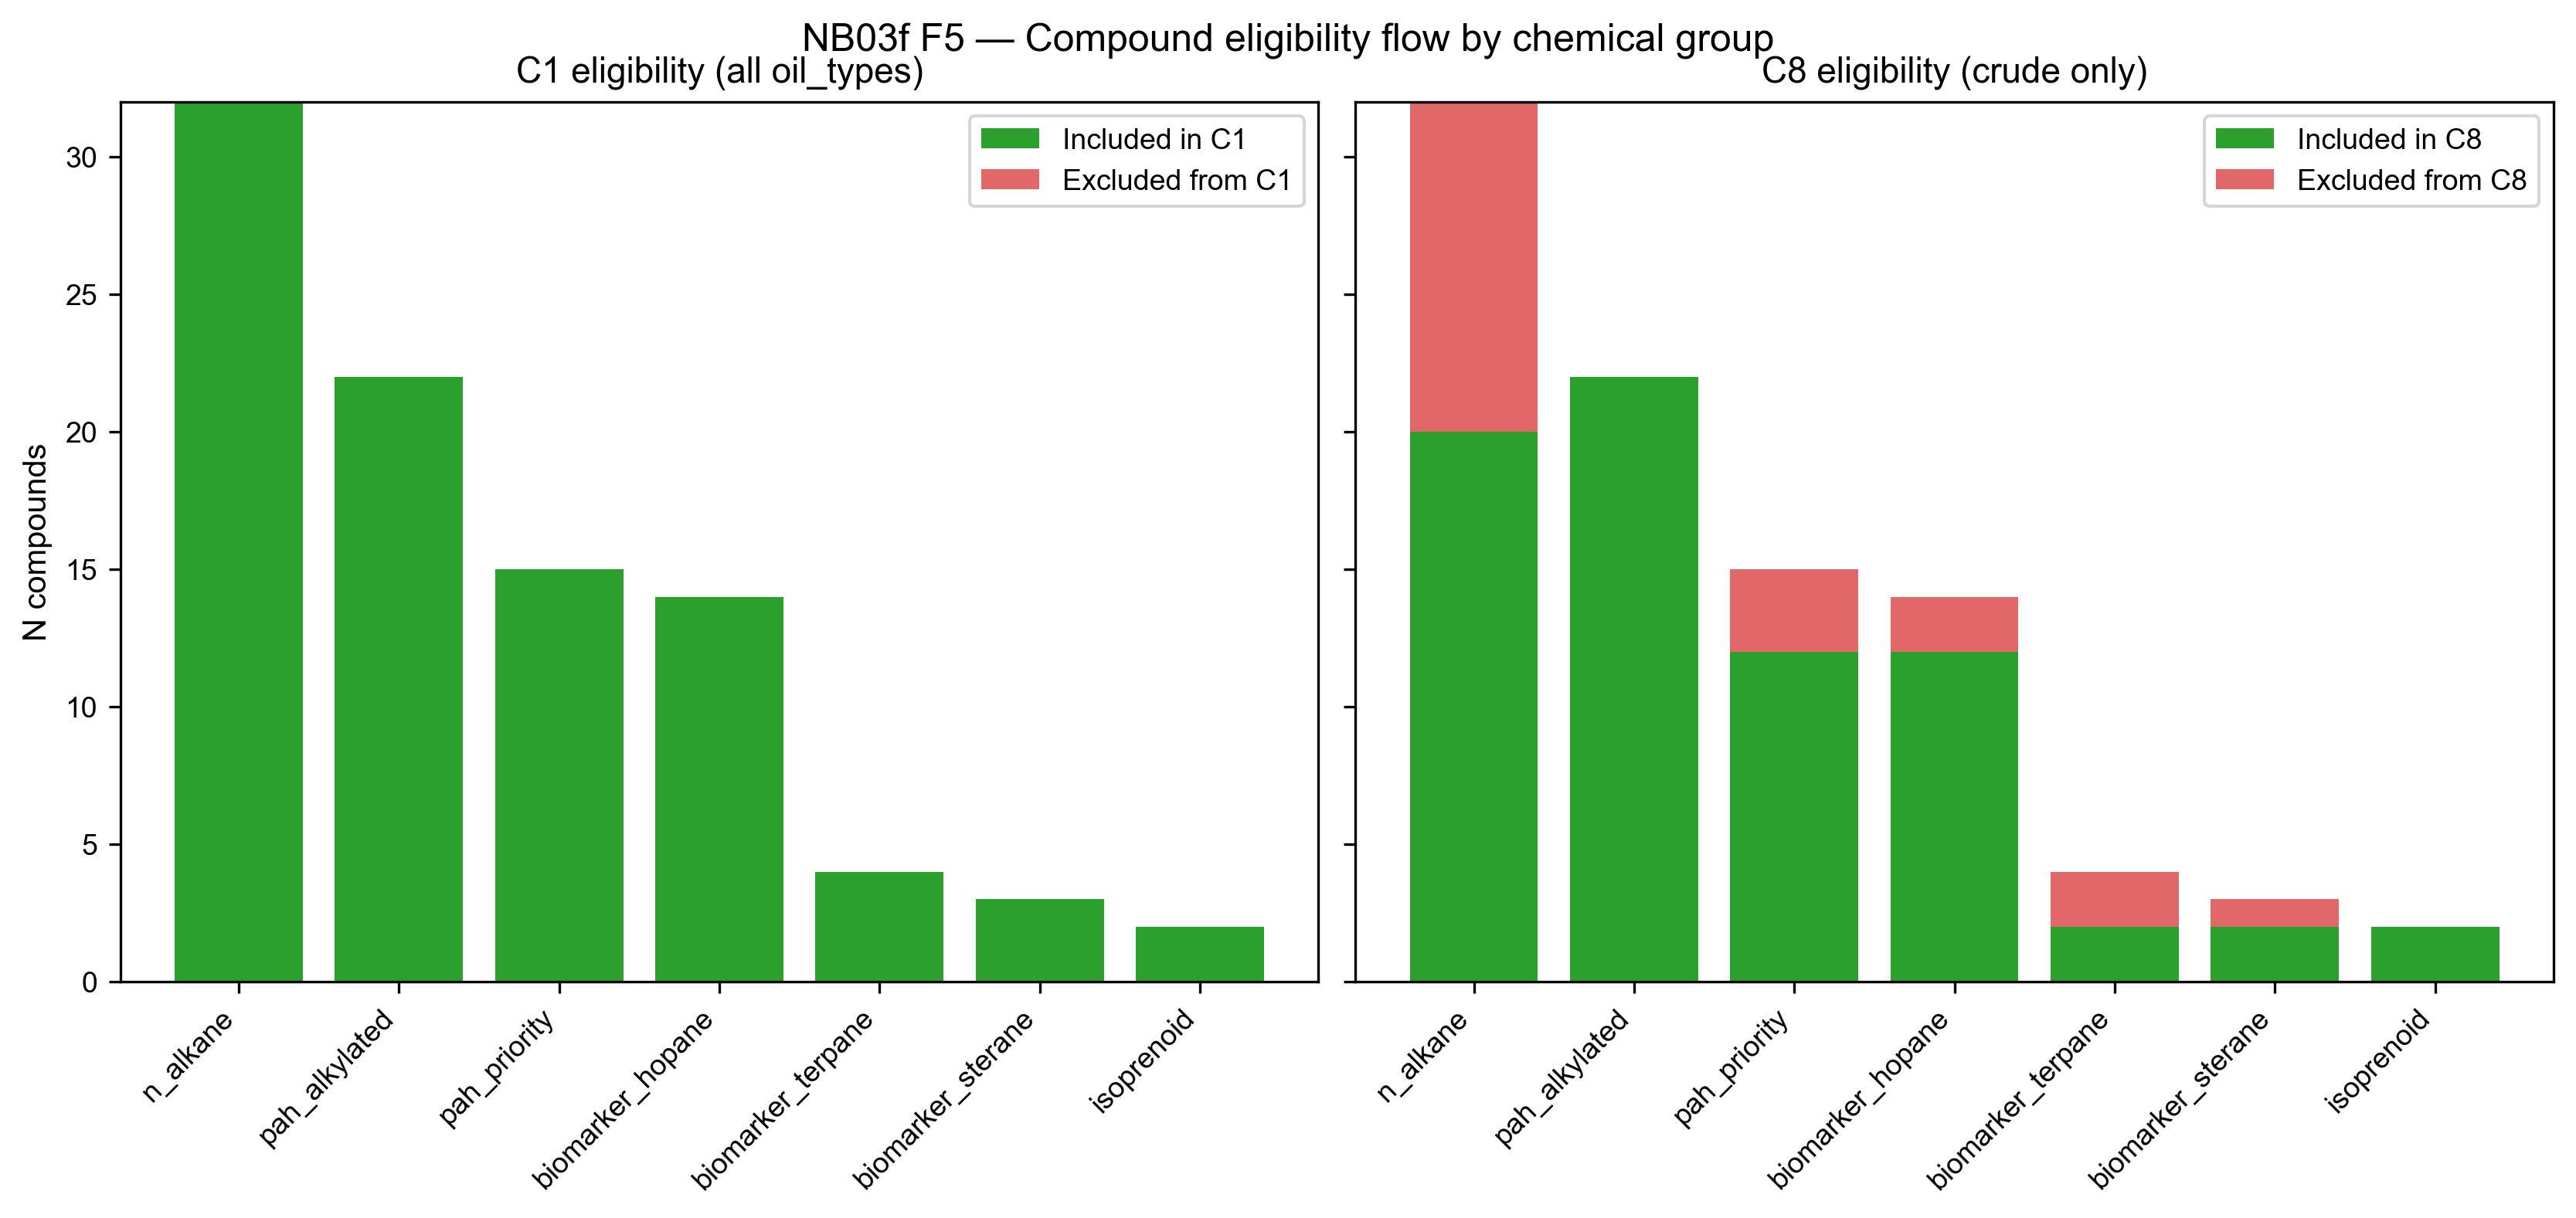

✅ F5 saved


In [20]:
# Cell S9.2 — Figure F5: feature eligibility flow

flow = (profile_df[profile_df['feature_kind'] == 'compound']
        .groupby('feature_group')
        .agg(
            n_total=('feature_name', 'count'),
            n_c1=('included_c1', 'sum'),
            n_c8=('included_c8', 'sum'),
        )
        .reset_index())
flow['excluded_c1'] = flow['n_total'] - flow['n_c1']
flow['excluded_c8'] = flow['n_total'] - flow['n_c8']
flow = flow.sort_values('n_total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

x = np.arange(len(flow))
axes[0].bar(x, flow['n_c1'], color='#2ca02c', label='Included in C1')
axes[0].bar(x, flow['excluded_c1'], bottom=flow['n_c1'],
            color='#d62728', alpha=0.7, label='Excluded from C1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(flow['feature_group'], rotation=45, ha='right')
axes[0].set_ylabel('N compounds')
axes[0].set_title('C1 eligibility (all oil_types)')
axes[0].legend()

axes[1].bar(x, flow['n_c8'], color='#2ca02c', label='Included in C8')
axes[1].bar(x, flow['excluded_c8'], bottom=flow['n_c8'],
            color='#d62728', alpha=0.7, label='Excluded from C8')
axes[1].set_xticks(x)
axes[1].set_xticklabels(flow['feature_group'], rotation=45, ha='right')
axes[1].set_title('C8 eligibility (crude only)')
axes[1].legend()

fig.suptitle('NB03f F5 — Compound eligibility flow by chemical group',
             y=1.02, fontsize=12)
fig.savefig(FIG_DIR / 'F5_feature_eligibility_sankey.png', bbox_inches='tight')
display(Image(filename=str(FIG_DIR / 'F5_feature_eligibility_sankey.png')))
plt.close(fig)
print('✅ F5 saved')

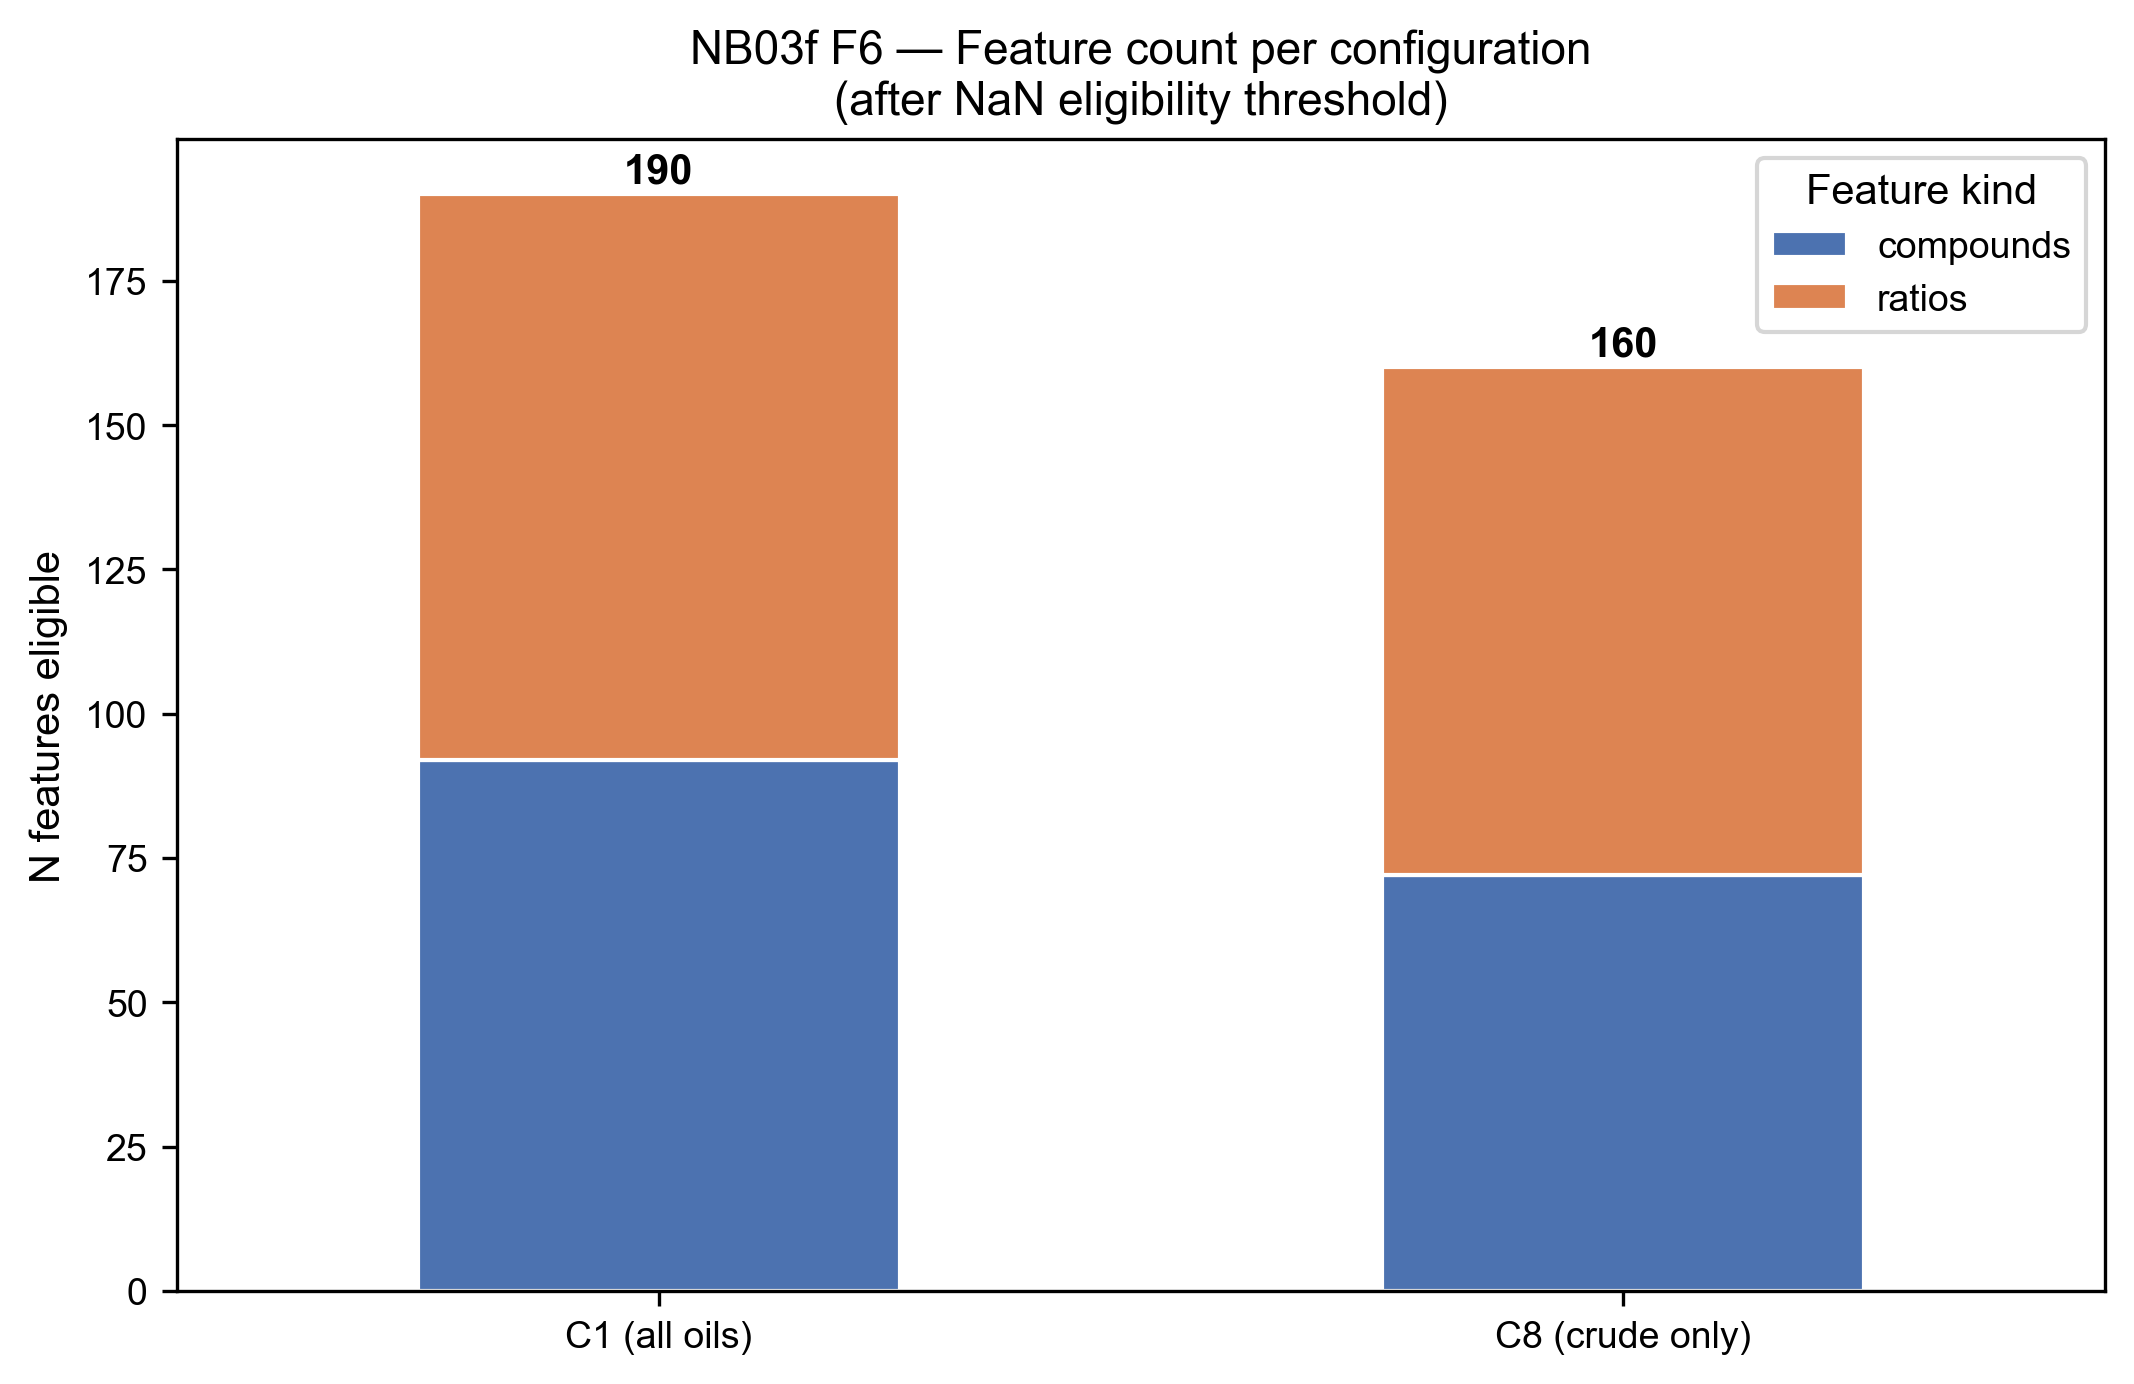

✅ F6 saved


In [21]:
# Cell S9.3 — Figure F6: final feature count per config

count_summary = {
    'C1 (all oils)': {
        'compounds': int(((profile_df['feature_kind'] == 'compound') &
                          profile_df['included_c1']).sum()),
        'ratios':    int(((profile_df['feature_kind'] == 'ratio') &
                          profile_df['included_c1']).sum()),
    },
    'C8 (crude only)': {
        'compounds': int(((profile_df['feature_kind'] == 'compound') &
                          profile_df['included_c8']).sum()),
        'ratios':    int(((profile_df['feature_kind'] == 'ratio') &
                          profile_df['included_c8']).sum()),
    },
}
count_df = pd.DataFrame(count_summary).T

fig, ax = plt.subplots(figsize=(7, 4.5))
count_df.plot(kind='bar', stacked=True, ax=ax,
              color=['#4c72b0', '#dd8452'], edgecolor='white')
for i, (cfg, row) in enumerate(count_df.iterrows()):
    total = int(row.sum())
    ax.text(i, total + 2, str(total), ha='center', fontweight='bold')
ax.set_ylabel('N features eligible')
ax.set_title('NB03f F6 — Feature count per configuration\n'
             '(after NaN eligibility threshold)')
ax.legend(title='Feature kind')
plt.xticks(rotation=0)
fig.savefig(FIG_DIR / 'F6_final_feature_count_barplot.png', bbox_inches='tight')
display(Image(filename=str(FIG_DIR / 'F6_final_feature_count_barplot.png')))
plt.close(fig)
print('✅ F6 saved')

---
## Section 10 — Stratified Filtering Diagnostic (Decisions 1c, 1d)

Protect NB03g from two failure modes of blind correlation filtering:
(a) collapsing globally redundant ratio pairs that diverge conditionally in minority oil_types,
causing **underfitting-by-amputation** in distribution tails;
(b) applying a uniform threshold that silently strips minority-class features below usability.

**Scope:** Diagnostic only -- no feature is dropped here.
Outputs: `feature_conditional_value` table + F7 figure + 2 treatment_decisions rows (1c, 1d).

In [22]:
# Cell S10.1 — Conditional correlation divergence

CORR_HIGH = 0.95          # matches NB03g redundancy threshold
DIVERGENCE_LOW = 0.80     # "no longer redundant in this group"
MIN_N_PER_GROUP = 20      # was 4; require >=20 samples to avoid spurious
                          # divergence (synthetic n=8 CI too wide)

df_ratios_long = pd.read_sql("""
    SELECT dr.oil_id, o.oil_type, dr.stage_code,
           dr.ratio_name, dr.value
    FROM diagnostic_ratios dr
    JOIN oils o ON dr.oil_id = o.oil_id
    WHERE o.include_in_analysis = 1 AND dr.value IS NOT NULL
""", conn)

df_w = (df_ratios_long
        .pivot_table(index=['oil_id', 'oil_type', 'stage_code'],
                     columns='ratio_name', values='value')
        .reset_index())

ratio_cols = [c for c in df_w.columns
              if c not in ('oil_id', 'oil_type', 'stage_code')]

# Global and per-oil_type correlation matrices
corr_global = df_w[ratio_cols].corr(method='pearson', min_periods=10)

corr_by_type = {}
for ot in df_w['oil_type'].dropna().unique():
    sub = df_w[df_w['oil_type'] == ot]
    if len(sub) < MIN_N_PER_GROUP:
        corr_by_type[ot] = ('skipped_small_n', len(sub))
        continue
    corr_by_type[ot] = sub[ratio_cols].corr(method='pearson', min_periods=3)

# Identify conditionally-divergent pairs
conditional_pairs = []
for i, r1 in enumerate(ratio_cols):
    for r2 in ratio_cols[i+1:]:
        rho_g = corr_global.loc[r1, r2]
        if pd.isna(rho_g) or abs(rho_g) < CORR_HIGH:
            continue
        min_abs_rho, min_ot = 1.0, None
        for ot, cm in corr_by_type.items():
            if isinstance(cm, tuple):
                continue
            rho_c = cm.loc[r1, r2]
            if pd.notna(rho_c) and abs(rho_c) < min_abs_rho:
                min_abs_rho, min_ot = abs(rho_c), ot
        if min_abs_rho < DIVERGENCE_LOW:
            conditional_pairs.append({
                'ratio_a': r1, 'ratio_b': r2,
                'rho_global': float(rho_g),
                'rho_min_abs': float(min_abs_rho),
                'divergent_in': min_ot,
                'divergence_gap': float(abs(rho_g) - min_abs_rho),
            })

df_cond = (pd.DataFrame(conditional_pairs)
           .sort_values('divergence_gap', ascending=False)
           .reset_index(drop=True))

print(f'Conditionally-divergent pairs flagged: {len(df_cond)}')
if len(df_cond) > 0:
    print(df_cond.head(15).to_string(index=False))

Conditionally-divergent pairs flagged: 26
      ratio_a       ratio_b  rho_global  rho_min_abs  divergent_in  divergence_gap
  C0Chr_C2Chr   C0Chr_C3Chr    0.996685     0.132457       refined        0.864228
  C0Chr_C1Chr   C0Chr_C3Chr    0.994064     0.237743 bitumen_blend        0.756321
    Pr_C29est      nC17_H30    0.974033     0.227993         crude        0.746040
    Pr_C29est      nC18_H30    0.966571     0.250070         crude        0.716501
  C0BNT_C4BNT   C3BNT_C4BNT    0.997199     0.381874 bitumen_blend        0.615325
  C0Chr_C1Chr   C0Chr_C2Chr    0.999122     0.415154 bitumen_blend        0.583968
       Pr_H30   nC13_C29est    0.953106     0.390787         crude        0.562319
C2Fluo_C4Fluo C3Fluo_C4Fluo    0.965816     0.453493         crude        0.512324
C1Fluo_C3Fluo C2Fluo_C3Fluo    0.955014     0.481465 bitumen_blend        0.473548
    Pr_C29est   nC13_C29est    0.991276     0.524367         crude        0.466908
C1Fluo_C4Fluo C2Fluo_C3Fluo    0.959842     0

In [23]:
# Cell S10.2 — Feature coverage audit by oil_type

NONNAN_FRACTION = 0.80
MIN_COVERAGE_PRESERVATION = 0.60   # NB03g gate as fraction of pre-filter baseline

coverage_rows = []
for ot in df_w['oil_type'].dropna().unique():
    sub = df_w[df_w['oil_type'] == ot][ratio_cols]
    n_samples = len(sub)
    if n_samples == 0:
        continue
    threshold_n = max(3, int(np.ceil(NONNAN_FRACTION * n_samples)))
    n_features_ok = int((sub.notna().sum() >= threshold_n).sum())
    coverage_rows.append({
        'oil_type': ot,
        'n_samples': n_samples,
        'n_features_covered': n_features_ok,
        'fraction_covered': n_features_ok / len(ratio_cols),
    })

# D-BOTTLENECK-RESOLVED-28ABR: bottleneck = lowest fraction_covered (geochemistry-correct),
# NOT lowest n_samples. Aligns this print with cell S10.4 (which already used coverage)
# and with NB03g Gate 1d. Refined (n=7, ~59% cov) is more fragile than synthetic
# (n=8, ~91% cov) on the joint per-feature × per-sample dimension that matters
# for downstream feature-coverage gates.
df_cov = (pd.DataFrame(coverage_rows)
          .sort_values('fraction_covered')
          .reset_index(drop=True))

print(df_cov.to_string(index=False))

bottleneck = df_cov.iloc[0]
print(f"\nBottleneck class (lowest coverage): {bottleneck['oil_type']} "
      f"(n={bottleneck['n_samples']}, coverage={bottleneck['fraction_covered']:.2%})")

     oil_type  n_samples  n_features_covered  fraction_covered
    synthetic          8                  98          0.907407
      refined         26                  64          0.592593
bitumen_blend         30                  88          0.814815
        crude        146                  88          0.814815

Bottleneck class: synthetic (n=8, coverage=90.74%)


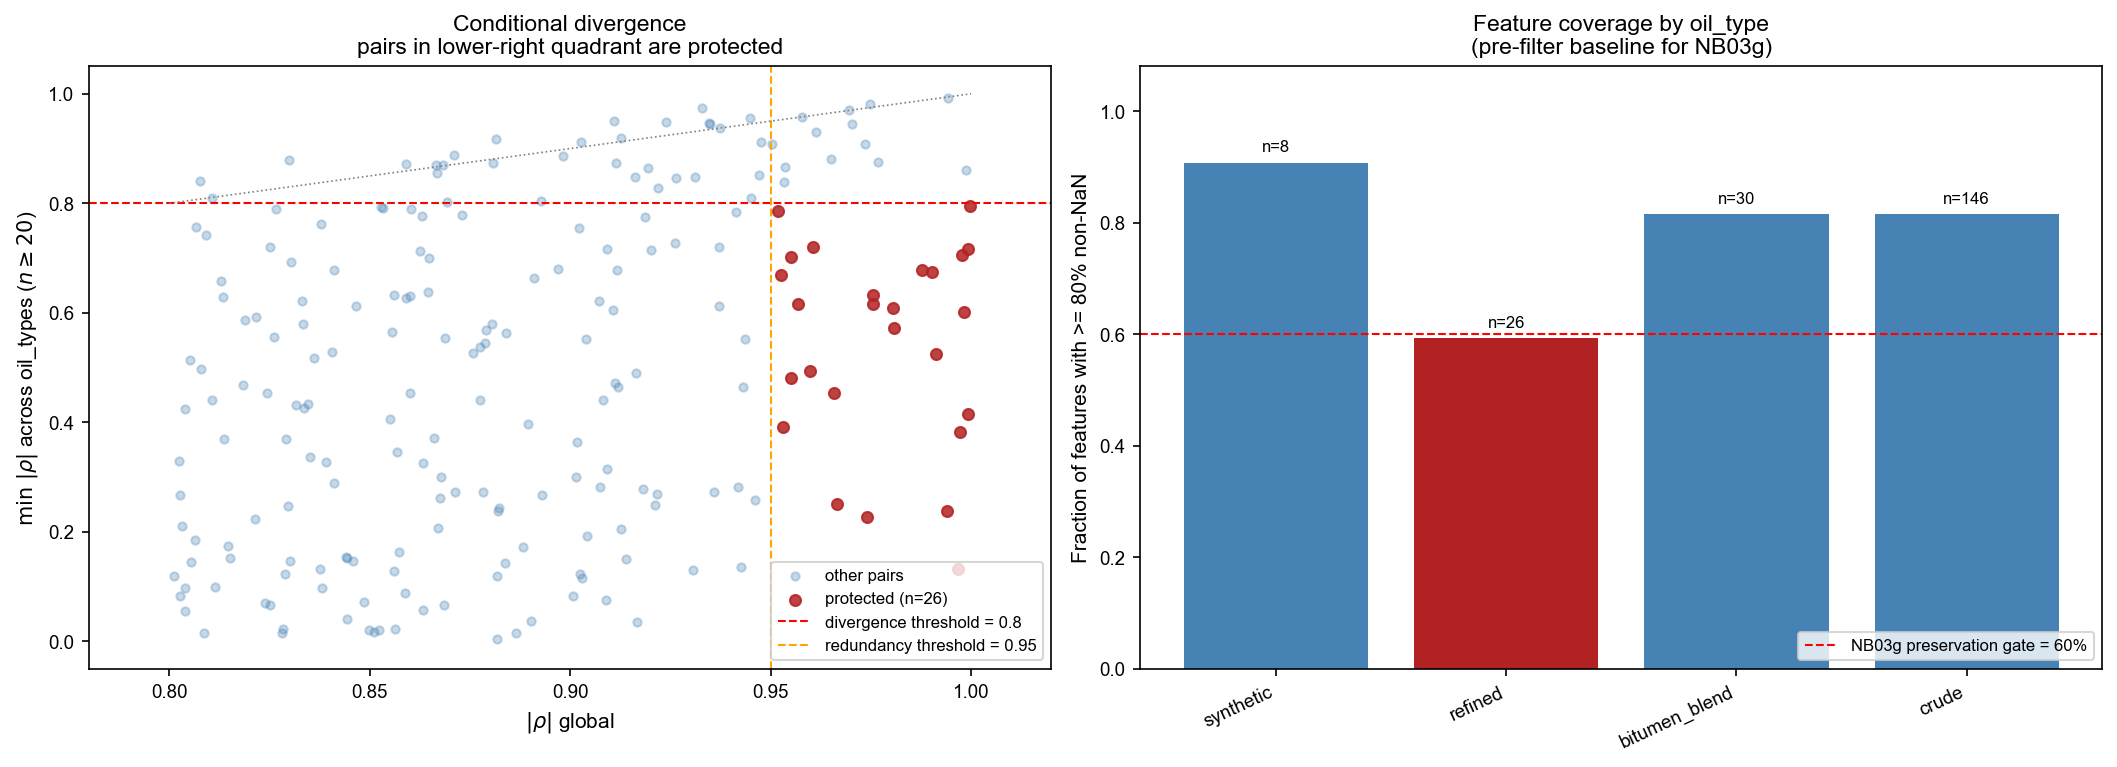

✅ F7 saved


In [24]:
# Cell S10.3 — Figure F7: conditional divergence + coverage diagnostic

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: |rho|_global vs min|rho|_per_oil_type
pairs_all = []
for i, r1 in enumerate(ratio_cols):
    for r2 in ratio_cols[i+1:]:
        rho_g = corr_global.loc[r1, r2]
        if pd.isna(rho_g) or abs(rho_g) < 0.80:
            continue
        min_abs = 1.0
        for ot, cm in corr_by_type.items():
            if isinstance(cm, tuple):
                continue
            rho_c = cm.loc[r1, r2]
            if pd.notna(rho_c) and abs(rho_c) < min_abs:
                min_abs = abs(rho_c)
        pairs_all.append((abs(rho_g), min_abs))

ax = axes[0]
if pairs_all:
    xs, ys = zip(*pairs_all)
    xs_arr, ys_arr = np.array(xs), np.array(ys)
    dmask = np.array([(x >= CORR_HIGH) and (y < DIVERGENCE_LOW) for x, y in zip(xs, ys)])
    ax.scatter(xs_arr[~dmask], ys_arr[~dmask], alpha=0.3, s=16,
               color='steelblue', label='other pairs')
    ax.scatter(xs_arr[dmask], ys_arr[dmask], alpha=0.85, s=28,
               color='firebrick', label=f'protected (n={dmask.sum()})')
ax.axhline(DIVERGENCE_LOW, ls='--', color='red', lw=1,
           label=f'divergence threshold = {DIVERGENCE_LOW}')
ax.axvline(CORR_HIGH, ls='--', color='orange', lw=1,
           label=f'redundancy threshold = {CORR_HIGH}')
ax.plot([0.8, 1], [0.8, 1], ls=':', color='gray', lw=0.8)
ax.set_xlabel(r'$|\rho|$ global')
ax.set_ylabel(r'$\min\ |\rho|$ across oil_types ($n \geq 20$)')
ax.set_title('Conditional divergence\npairs in lower-right quadrant are protected')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0.78, 1.02)
ax.set_ylim(-0.05, 1.05)

# Panel B: coverage bars
ax = axes[1]
colors = ['steelblue' if f >= MIN_COVERAGE_PRESERVATION else 'firebrick'
          for f in df_cov['fraction_covered']]
ax.bar(df_cov['oil_type'], df_cov['fraction_covered'], color=colors)
ax.axhline(MIN_COVERAGE_PRESERVATION, ls='--', color='red', lw=1,
           label=f'NB03g preservation gate = {MIN_COVERAGE_PRESERVATION:.0%}')
ax.set_ylabel(f'Fraction of features with >= {int(NONNAN_FRACTION*100)}% non-NaN')
ax.set_title('Feature coverage by oil_type\n(pre-filter baseline for NB03g)')
ax.set_ylim(0, 1.08)
for i_bar, (ot, n) in enumerate(zip(df_cov['oil_type'], df_cov['n_samples'])):
    ax.text(i_bar, df_cov['fraction_covered'].iloc[i_bar] + 0.02,
            f'n={n}', ha='center', fontsize=8)
ax.legend(fontsize=8, loc='lower right')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')

fig.savefig(FIG_DIR / 'F7_stratified_filter_diagnostic.png',
            bbox_inches='tight', dpi=150)
display(Image(filename=str(FIG_DIR / 'F7_stratified_filter_diagnostic.png')))
plt.close(fig)
print('\u2705 F7 saved')

In [25]:
# Cell S10.4 — Persist feature_conditional_value + stage NB03g gates

cur.executescript("""
CREATE TABLE IF NOT EXISTS feature_conditional_value (
    ratio_a         TEXT NOT NULL,
    ratio_b         TEXT NOT NULL,
    rho_global      REAL NOT NULL,
    rho_min_abs     REAL NOT NULL,
    divergent_in    TEXT,
    divergence_gap  REAL NOT NULL,
    protect_flag    INTEGER NOT NULL DEFAULT 1,
    created_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (ratio_a, ratio_b)
);
""")
cur.execute('DELETE FROM feature_conditional_value')

if len(df_cond) > 0:
    (df_cond[['ratio_a', 'ratio_b', 'rho_global', 'rho_min_abs',
              'divergent_in', 'divergence_gap']]
        .assign(protect_flag=1)
        .to_sql('feature_conditional_value', conn,
                if_exists='append', index=False))
conn.commit()

# Bottleneck = lowest COVERAGE (greatest risk of falling below gate after
# NB03g filter), NOT smallest n_samples. A class with n=8 but 90% coverage
# is safer than a class with n=26 but 62% coverage.
bottleneck_row = df_cov.sort_values('fraction_covered').iloc[0]
baseline_cov = float(bottleneck_row['fraction_covered'])
bottleneck_ot = str(bottleneck_row['oil_type'])
n_cond_pairs = len(df_cond)

policy_1c = (f'Protect {n_cond_pairs} conditionally-divergent pairs '
             f'(|rho_global|>={CORR_HIGH}, min|rho_oil_type|<{DIVERGENCE_LOW}) '
             f'from NB03g correlation filter. Reference: feature_conditional_value.')
policy_1d = (f'NB03g post-filter coverage for {bottleneck_ot} must be '
             f'>= {MIN_COVERAGE_PRESERVATION:.0%} of pre-filter baseline '
             f'({baseline_cov:.2%}). Abort and report offending features otherwise.')

print(f'feature_conditional_value: {n_cond_pairs} protected pairs')
print(f'policy_1c / policy_1d staged for Cell Final')
print(f'  bottleneck oil_type = {bottleneck_ot} (baseline coverage {baseline_cov:.2%})')

feature_conditional_value: 26 protected pairs
policy_1c / policy_1d staged for Cell Final
  bottleneck oil_type = refined (baseline coverage 59.26%)


---
## Final — Summary, treatment_decisions, and JSON export

In [26]:
# Cell Final — Persist treatment_decisions and export JSON

cur.executescript("""
CREATE TABLE IF NOT EXISTS treatment_decisions (
    decision_id        TEXT PRIMARY KEY,
    decision_name      TEXT NOT NULL,
    policy             TEXT NOT NULL,
    scope              TEXT,
    rationale          TEXT,
    threshold_nan_pct  REAL,
    created_at         TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
""")
cur.execute('DELETE FROM treatment_decisions')

decisions = [
    ('1a', 'feature_eligibility',
     '>=80% presence in >=1 relevant oil_type',
     'global (C1: all types; C8: crude only)',
     'MNAR structural excluded; XGBoost native NaN handles MNAR-LOD and variation.',
     0.20),
    ('1b', 'imputation_policy',
     'ND->0 (D15, NB01) only; no additional imputation',
     'global',
     'GUARDRAILS 3b. KNN/MICE/iterative forbidden.',
     None),
    ('1c', 'conditional_divergence_protection',
     policy_1c,
     'NB03g correlation filter',
     'Pairs globally redundant but conditionally divergent carry signal that '
     'the r>0.95 filter would destroy. Identified in NB03f S10.1.',
     None),
    ('1d', 'minority_class_coverage_gate',
     policy_1d,
     'NB03g filter acceptance',
     'Bottleneck oil_type coverage must be preserved proportionally after NB03g filter. '
     'Baseline measured in NB03f S10.2.',
     None),
    ('2', 'winsorization',
     'none (descriptive skew/kurt only)',
     'global',
     'XGBoost invariant to monotone transformations; trimming alters Wilcoxon signal.',
     None),
    ('3', 'log_transform',
     'np.log1p applied to C4, C4b, Ridge only',
     'PER-FOLD: after imputation, before z-score',
     'Variance stabilization for PCA/linear; trees invariant.',
     None),
    ('4', 'nan_imputation_per_config',
     'XGBoost native (C1/C2/C3/C5/C8/C2i/C4c); median per-fold (C4/C4b/C6/Ridge)',
     'PER-FOLD inside LOOO -- NEVER global',
     'Per-fold prevents C4c-style leakage. sklearn RF (C6) requires imputation.',
     None),
    ('5', 'scaling',
     'z-score per-fold for C4, C4b, Ridge',
     'PER-FOLD inside LOOO',
     'Required by PCA and Ridge; trees invariant.',
     None),
    ('6', 'log_ratio_redundancy',
     'keep linear if |rho|>0.98 and min(lin)>=0.05; keep log if min(lin)<0.05',
     'global (downstream feature selection applies the drop)',
     'Redundancy cutoff with numerical-stability exception.',
     None),
    ('7', 'tph_normalization',
     'not applied; keep D17 mass-loss correction',
     'global',
     'TPH-norm removes concentration effect on recalcitrants (weathering signal).',
     None),
    ('8', 'missingness_binary_features',
     'not created',
     'global',
     'XGBoost native sparsity-aware split is mathematically equivalent.',
     None),
    ('9', 'shap_grouping',
     f'{n_groups} chemical hierarchies for SHAP aggregation',
     'NB06 SHAP aggregation',
     'Coarser than DP41 per-ratio grouping; publication-level interpretation.',
     None),
]
cur.executemany("""
INSERT INTO treatment_decisions
(decision_id, decision_name, policy, scope, rationale, threshold_nan_pct)
VALUES (?, ?, ?, ?, ?, ?)
""", decisions)
conn.commit()

n_dec = cur.execute('SELECT COUNT(*) FROM treatment_decisions').fetchone()[0]
assert n_dec == 12, f'Expected 12 decision rows (1a-1d + 2..9), got {n_dec}'

# JSON export 1 — treatment_decisions.json
decisions_json = {
    'generated_at': pd.Timestamp.now().isoformat(),
    'nb03f_version': 'v1.0',
    'pipeline_ref': 'GUARDRAILS v2.15 3b, 16; PROJETO v5.18 10.2b',
    'decisions': {
        d[0]: {'name': d[1], 'policy': d[2], 'scope': d[3],
               'rationale': d[4], 'threshold_nan_pct': d[5]}
        for d in decisions
    },
}
(NB_OUT_DIR / 'treatment_decisions.json').write_text(
    json.dumps(decisions_json, indent=2)
)

# JSON export 2 — shap_feature_groups.json
shap_json = {
    'generated_at': pd.Timestamp.now().isoformat(),
    'n_groups': n_groups,
    'groups': shap_groups_def,
}
(NB_OUT_DIR / 'shap_feature_groups.json').write_text(
    json.dumps(shap_json, indent=2)
)

# Final invariant check: measurements untouched
n_null_after = cur.execute(
    'SELECT COUNT(*) FROM measurements WHERE value_imputed IS NULL'
).fetchone()[0]
assert n_null_after == n_null_before, (
    f'INVARIANT VIOLATED: measurements NULLs changed from {n_null_before} to {n_null_after}'
)

# Final summary
print('=' * 68)
print('NB03f SUMMARY \u2014 Data Treatment Decisions')
print('=' * 68)
print(f'  Features eligible C1 (all oils):       {n_c1}')
print(f'  Features eligible C8 (crude only):     {n_c8}')
print(f'  Jaccard(C1, C8):                       {jaccard_c1_c8:.3f}')
print(f'  Features flagged |skew| > 5:           {len(high_skew)}')
print(f'  Log-ratio pairs analyzed:              {len(redund_df)}')
print(f'  Conditional-divergence pairs protected: {n_cond_pairs}')
print(f'  SHAP groups persisted:                 {n_groups}')
print(f'  Decisions recorded:                    {n_dec}  (9 buckets; Decision 1 -> 1a/1b/1c/1d)')
print(f'  Figures written to:                    {FIG_DIR}')
print(f'  Policy JSONs written to:               {NB_OUT_DIR}')
print()
print()
print('The pipeline identified the treatment policies above.')
print('NB03f did NOT mutate measurements or diagnostic_ratios.')
print('Downstream notebooks (NB04+) MUST apply these policies per-fold.')

conn.close()
print('\n\u2705 NB03f complete')

NB03f SUMMARY — Data Treatment Decisions
  Features eligible C1 (all oils):       190
  Features eligible C8 (crude only):     160
  Jaccard(C1, C8):                       0.842
  Features flagged |skew| > 5:           28
  Log-ratio pairs analyzed:              0
  Conditional-divergence pairs protected: 26
  SHAP groups persisted:                 16
  Decisions recorded:                    12  (9 buckets; Decision 1 -> 1a/1b/1c/1d)
  Figures written to:                    C:\Users\leogr\Documents\Data Science\TCC\figures\nb03f
  Policy JSONs written to:               C:\Users\leogr\Documents\Data Science\TCC\data\processed\nb03f_policies

Vocabulary discipline check (GUARDRAILS 16):
  - Tier 1 / Tier 2 / Tier 3 used exclusively
  - No process/identity binary labels

The pipeline identified the treatment policies above.
NB03f did NOT mutate measurements or diagnostic_ratios.
Downstream notebooks (NB04+) MUST apply these policies per-fold.

✅ NB03f complete
